# Corrosion Detection — All Methods Comparison

This notebook is the part where we compare all five methods, and compute their rejection threshold


The five representation learning approaches includes:
Supervised (ResNet18), SimCLR, SupCon, BYOL, and ViT-Base.

**Structure**
- Section 0 — Shared setup (imports, config, transforms, data, utilities)
- Section 1 — Supervised
- Section 2 — SimCLR
- Section 3 — SupCon
- Section 4 — BYOL
- Section 5 — ViT-Base
- Section 6 — Final comparison

## Section 0 — Shared Setup

In [1]:
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models.feature_extraction import create_feature_extractor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.decomposition import PCA

In [2]:
# config
SEED        = 42
IMG_SIZE    = 224
NUM_WORKERS = 0

DATA_ROOT    = Path('dataset_ood')
TRAIN_DIR    = DATA_ROOT / 'train'
VAL_DIR      = DATA_ROOT / 'val'
TEST_DIR     = DATA_ROOT / 'test'
VAL_OOD_DIR  = DATA_ROOT / 'val_ood'
TEST_OOD_DIR = DATA_ROOT / 'test_ood'

# Supervised
SUP_LR     = 1e-3
SUP_EPOCHS = 10
SUP_BATCH  = 32

# SimCLR
SIMCLR_PROJ_DIM = 128
SIMCLR_TEMP     = 0.07
SIMCLR_LR       = 3e-4
SIMCLR_EPOCHS   = 50
SIMCLR_BATCH    = 256

# SupCon
SUPCON_PROJ_DIM = 128
SUPCON_TEMP     = 0.1
SUPCON_LR       = 0.125
SUPCON_BATCH    = 256
SUPCON_EPOCHS   = 50

# BYOL
BYOL_PROJ_DIM  = 256
BYOL_PRED_DIM  = 256
BYOL_HIDDEN    = 512
BYOL_LR        = 3e-4
BYOL_EPOCHS    = 80
BYOL_BATCH     = 128
BYOL_EMA_DECAY = 0.999

# ViT
VIT_MODEL_NAME = 'google/vit-base-patch16-224'
VIT_LR         = 2e-5
VIT_EPOCHS     = 10
VIT_BATCH      = 32

# OOD
CORROSION_IDX  = 0   # class index for CORROSION

In [3]:
# device setup

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using Apple MPS')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Using CUDA')
else:
    DEVICE = torch.device('cpu')
    print('Using CPU')


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Using Apple MPS


In [4]:
# Transforms

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomGrayscale(p=0.2),   # improve robustness for baseline model
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

contrastive_base_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class TwoCropTransform:
    """Returns two independently augmented views of the same image."""
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return [self.transform(x), self.transform(x)]


two_crop_tf = TwoCropTransform(contrastive_base_tf)

In [5]:
# Datasets
train_ds_sup     = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds_sup       = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)
train_ds_twocrop = datasets.ImageFolder(TRAIN_DIR, transform=two_crop_tf)
train_ds_eval    = datasets.ImageFolder(TRAIN_DIR,    transform=eval_tf)
val_ds_eval      = datasets.ImageFolder(VAL_DIR,      transform=eval_tf)
test_ds_eval     = datasets.ImageFolder(TEST_DIR,     transform=eval_tf)
val_ood_ds       = datasets.ImageFolder(VAL_OOD_DIR,  transform=eval_tf)
test_ood_ds      = datasets.ImageFolder(TEST_OOD_DIR, transform=eval_tf)

CLASS_NAMES = train_ds_sup.classes
NUM_CLASSES = len(CLASS_NAMES)
print('Classes:',       CLASS_NAMES)
print('Train samples:', len(train_ds_sup))
print('Val samples:',   len(val_ds_eval))
print('Test samples:',  len(test_ds_eval))
print('Val OOD:',       len(val_ood_ds))
print('Test OOD:',      len(test_ood_ds))

# DataLoaders
train_dl_sup     = DataLoader(train_ds_sup,     batch_size=SUP_BATCH,     shuffle=True,  num_workers=NUM_WORKERS)
val_dl_sup       = DataLoader(val_ds_sup,       batch_size=SUP_BATCH,     shuffle=False, num_workers=NUM_WORKERS)
train_dl_simclr  = DataLoader(train_ds_twocrop, batch_size=SIMCLR_BATCH,  shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
train_dl_twocrop = DataLoader(train_ds_twocrop, batch_size=SUPCON_BATCH,  shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
train_dl_byol    = DataLoader(train_ds_twocrop, batch_size=BYOL_BATCH,    shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
train_dl_eval    = DataLoader(train_ds_eval,    batch_size=SUP_BATCH,     shuffle=False, num_workers=NUM_WORKERS)
val_dl_eval      = DataLoader(val_ds_eval,      batch_size=SUP_BATCH,     shuffle=False, num_workers=NUM_WORKERS)
test_dl_eval     = DataLoader(test_ds_eval,     batch_size=SUP_BATCH,     shuffle=False, num_workers=NUM_WORKERS)
val_ood_dl       = DataLoader(val_ood_ds,       batch_size=SUP_BATCH,     shuffle=False, num_workers=NUM_WORKERS)
test_ood_dl      = DataLoader(test_ood_ds,      batch_size=SUP_BATCH,     shuffle=False, num_workers=NUM_WORKERS)

Classes: ['CORROSION', 'NOCORROSION']
Train samples: 2522
Val samples: 653
Test samples: 182
Val OOD: 364
Test OOD: 850


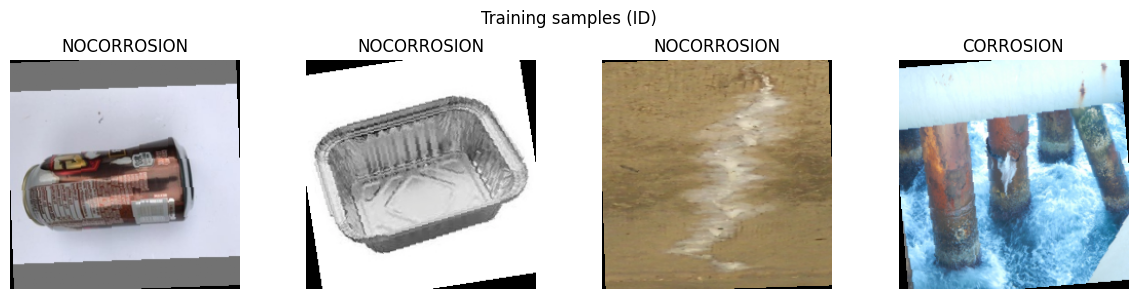

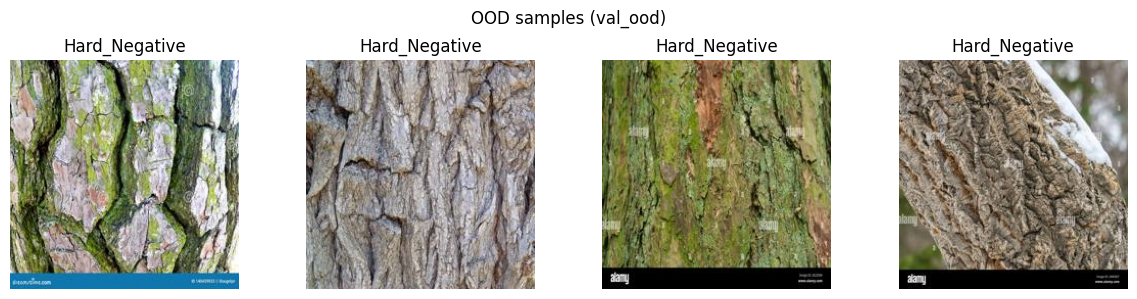

In [6]:
# visualisation

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img.cpu() * std + mean).clamp(0, 1)

images, labels = next(iter(train_dl_sup))
plt.figure(figsize=(12, 3))
for i in range(min(4, len(images))):
    plt.subplot(1, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis('off')
plt.suptitle('Training samples (ID)')
plt.tight_layout()
plt.show()

images, labels = next(iter(val_ood_dl))
plt.figure(figsize=(12, 3))
for i in range(min(4, len(images))):
    plt.subplot(1, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title('Hard_Negative')
    plt.axis('off')
plt.suptitle('OOD samples (val_ood)')
plt.tight_layout()
plt.show()

In [7]:
# shared feature extraction utilities

def l2_normalize_torch(Z, eps=1e-12):
    return Z / (Z.norm(dim=1, keepdim=True) + eps)


def extract_embeddings_resnet(feat_extractor, dataloader, device):
    """Extract avgpool features from a ResNet feature extractor."""
    feat_extractor.eval()
    all_emb, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            emb = feat_extractor(images.to(device))['emb']
            all_emb.append(torch.flatten(emb, 1).cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_emb), torch.cat(all_labels)


def extract_embeddings_contrastive(model, dataloader, device):
    """Extract backbone (h) and projection (z) features from SimCLR/SupCon."""
    model.eval()
    all_h, all_z, all_labels = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            h, z = model(images.to(device))
            all_h.append(h.cpu())
            all_z.append(z.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h), torch.cat(all_z), torch.cat(all_labels)


def extract_byol_features(model, dataloader, device):
    """Extract backbone features from BYOL online encoder."""
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            h = model.get_features(images.to(device))
            all_h.append(h.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h), torch.cat(all_labels)


def extract_vit_features(model, dataloader, device):
    """Extract ViT CLS token features."""
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            out = model.vit(pixel_values=images.to(device))
            cls = out.last_hidden_state[:, 0, :]  # [B, 768]
            all_h.append(cls.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h), torch.cat(all_labels)


def run_linear_probe(Z_train, y_train, Z_val, y_val):
    """Fit logistic regression on frozen features; return clf + train/val acc."""
    clf = LogisticRegression(max_iter=2000, solver='lbfgs', class_weight='balanced')
    clf.fit(Z_train.numpy(), y_train.numpy())
    tr_acc = accuracy_score(y_train.numpy(), clf.predict(Z_train.numpy()))
    vl_acc = accuracy_score(y_val.numpy(),   clf.predict(Z_val.numpy()))
    return clf, tr_acc, vl_acc

In [8]:
# OOD detection utilities

def compute_class_prototypes(Z, y, num_classes):
    """Mean feature per class in feature space."""
    return torch.stack([Z[y == c].mean(0) for c in range(num_classes)])


def cosine_confidence_scores(Z_l2, prototypes_l2):
    """Max cosine similarity from each sample to any class prototype."""
    return torch.mm(Z_l2, prototypes_l2.T).max(dim=1).values


def compute_auroc(id_scores, ood_scores):
    """AUROC: separating ID (label=1) from OOD (label=0)."""
    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    return roc_auc_score(labels, scores)


def tune_threshold(id_feat_val, y_val_np, ood_feat_vood, proto, steps=50):
    """Sweep cosine-sim thresholds on val_ood to find best operating point."""
    id_scores  = cosine_confidence_scores(id_feat_val,   proto).numpy()
    ood_scores = cosine_confidence_scores(ood_feat_vood, proto).numpy()
    id_preds   = torch.mm(id_feat_val, proto.T).argmax(dim=1).numpy()
    thresholds = np.linspace(
        np.concatenate([id_scores, ood_scores]).min(),
        np.concatenate([id_scores, ood_scores]).max(), steps
    )
    rows = []
    for t in thresholds:
        id_accept  = id_scores  >= t
        ood_reject = ood_scores <  t
        acc = accuracy_score(y_val_np[id_accept], id_preds[id_accept]) if id_accept.sum() > 0 else float('nan')
        rows.append({'threshold': float(t), 'id_coverage': float(id_accept.mean()),
                     'id_accepted_acc': float(acc), 'ood_reject_rate': float(ood_reject.mean())})
    return pd.DataFrame(rows)


def best_threshold(df, min_coverage=0.80):
    """Highest OOD reject rate with ID coverage >= min_coverage."""
    valid = df[df['id_coverage'] >= min_coverage].dropna()
    if valid.empty:
        return float(df.iloc[0]['threshold'])
    return float(valid.sort_values('ood_reject_rate', ascending=False).iloc[0]['threshold'])


def eval_ood_final(id_feat_test, y_test_np, ood_feat_tood, proto, threshold, name):
    """Final OOD evaluation on test_ood at chosen threshold."""
    id_scores  = cosine_confidence_scores(id_feat_test,  proto).numpy()
    ood_scores = cosine_confidence_scores(ood_feat_tood, proto).numpy()
    id_preds   = torch.mm(id_feat_test, proto.T).argmax(dim=1).numpy()
    auroc      = compute_auroc(id_scores, ood_scores)
    id_accept  = id_scores  >= threshold
    ood_reject = ood_scores <  threshold
    id_coverage     = id_accept.mean()
    ood_reject_rate = ood_reject.mean()
    id_acc_at_t     = accuracy_score(y_test_np[id_accept], id_preds[id_accept]) if id_accept.sum() > 0 else float('nan')
    print(f'\n  {name}')
    print(f'  Feature AUROC (ID vs OOD): {auroc:.4f}')
    print(f'  Threshold:                 {threshold:.4f}')
    print(f'  ID coverage:               {id_coverage:.4f}')
    print(f'  Accepted ID accuracy:      {id_acc_at_t:.4f}')
    print(f'  OOD reject rate:           {ood_reject_rate:.4f}')
    return {'method': name, 'feat_auroc': auroc, 'threshold': threshold,
            'id_coverage': id_coverage, 'id_acc_at_t': id_acc_at_t, 'ood_reject_rate': ood_reject_rate}


def visualize_feature_space(H_test, y_test_np, H_tood, class_names, title):
    """PCA scatter — ID test + OOD samples."""
    Z_all = np.concatenate([H_test.numpy(), H_tood.numpy()])
    y_all = np.concatenate([y_test_np, np.full(len(H_tood), len(class_names))])
    Z_2d  = PCA(n_components=2).fit_transform(Z_all)
    plt.figure(figsize=(6, 5))
    for c, cname in enumerate(class_names):
        mask = y_all == c
        plt.scatter(Z_2d[mask, 0], Z_2d[mask, 1], alpha=0.6, label=cname)
    mask_ood = y_all == len(class_names)
    plt.scatter(Z_2d[mask_ood, 0], Z_2d[mask_ood, 1], alpha=0.5, marker='x', color='red', label='OOD')
    plt.title(title); plt.xlabel('PC1'); plt.ylabel('PC2')
    plt.legend(); plt.tight_layout(); plt.show()


def plot_training_history(history, title):
    """Plot train/val loss (and acc if present)."""
    epochs = range(1, len(history.get('train_loss', history.get('loss', []))) + 1)
    if 'val_loss' in history:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(epochs, history['train_loss'], label='train')
        axes[0].plot(epochs, history['val_loss'],   label='val')
        axes[0].set_title(f'{title} — Loss'); axes[0].legend()
        axes[1].plot(epochs, history['train_acc'], label='train')
        axes[1].plot(epochs, history['val_acc'],   label='val')
        axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    else:
        plt.figure(figsize=(7, 4))
        plt.plot(epochs, history['train_loss'], label='train_loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(title); plt.legend()
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title); plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

---
## Section 1 — Supervised (ResNet18)
Full fine-tuning with differential LR: backbone 1e-4, head 1e-3. Cross-entropy loss, Adam, 10 epochs.

In [9]:
# Supervised model def and training functions

def make_resnet18_full(num_classes):
    """ResNet18 with ImageNet weights; all layers trainable."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, all_preds, all_labels = 0.0, [], []
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * images.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / len(dataloader.dataset), accuracy_score(all_labels, all_preds)


def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / len(dataloader.dataset), accuracy_score(all_labels, all_preds)


def fit_supervised_model(model, train_loader, val_loader, criterion, optimizer,
                         device, epochs=10, checkpoint_path=None):
    history  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_state = -1.0, None
    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = eval_one_epoch(model, val_loader,   criterion, device)
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
        print(f'Epoch {epoch+1:02d}/{epochs} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={vl_loss:.4f} acc={vl_acc:.4f}')
        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)
    if best_state:
        model.load_state_dict(best_state)
    return model, history, best_acc


sup_model = make_resnet18_full(NUM_CLASSES).to(DEVICE)
print(f'Supervised trainable params: {sum(p.numel() for p in sup_model.parameters() if p.requires_grad):,}')

Supervised trainable params: 11,177,538


Epoch 01/10 | train_loss=0.2730 acc=0.8751 | val_loss=0.2603 acc=0.8943
Epoch 02/10 | train_loss=0.1337 acc=0.9520 | val_loss=0.2913 acc=0.8943
Epoch 03/10 | train_loss=0.1264 acc=0.9485 | val_loss=0.2686 acc=0.8897
Epoch 04/10 | train_loss=0.0924 acc=0.9683 | val_loss=0.2792 acc=0.9035
Epoch 05/10 | train_loss=0.0989 acc=0.9603 | val_loss=0.3944 acc=0.8714
Epoch 06/10 | train_loss=0.0759 acc=0.9671 | val_loss=0.2423 acc=0.9005
Epoch 07/10 | train_loss=0.0479 acc=0.9794 | val_loss=0.3076 acc=0.9096
Epoch 08/10 | train_loss=0.0436 acc=0.9853 | val_loss=0.3394 acc=0.8882
Epoch 09/10 | train_loss=0.0470 acc=0.9853 | val_loss=0.4562 acc=0.8775
Epoch 10/10 | train_loss=0.0737 acc=0.9726 | val_loss=0.3926 acc=0.8867

Best supervised val acc: 0.9096


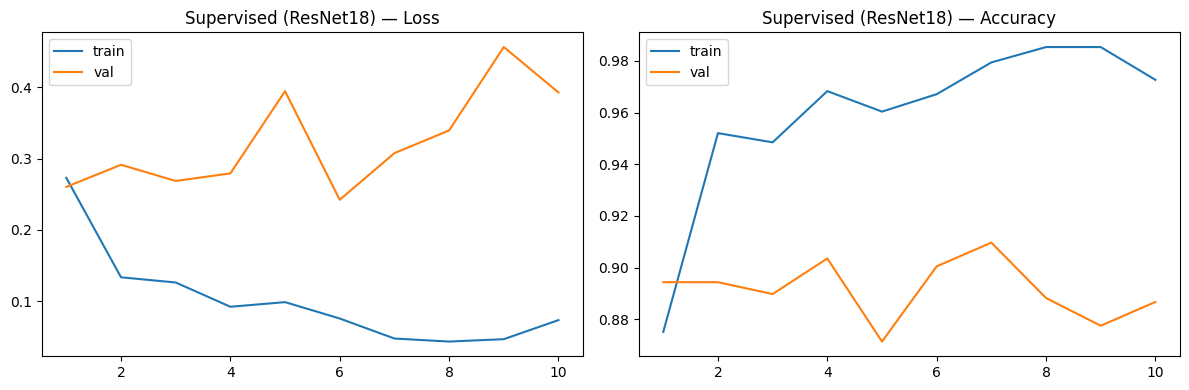

In [10]:
# Train supervised model
sup_criterion = nn.CrossEntropyLoss()
sup_optimizer = torch.optim.Adam([
    {'params': sup_model.fc.parameters(),                                       'lr': 1e-3},
    {'params': [p for n, p in sup_model.named_parameters() if 'fc' not in n], 'lr': 1e-4},
])

sup_model, sup_history, sup_best_val_acc = fit_supervised_model(
    sup_model, train_dl_sup, val_dl_sup, sup_criterion, sup_optimizer,
    DEVICE, epochs=SUP_EPOCHS, checkpoint_path='sup_best.pt'
)
print(f'\nBest supervised val acc: {sup_best_val_acc:.4f}')
plot_training_history(sup_history, 'Supervised (ResNet18)')

In [11]:
# Extract supervised features from avgpool (512 dim)
sup_feat_extractor = create_feature_extractor(sup_model, return_nodes={'avgpool': 'emb'}).to(DEVICE)

H_sup_train, y_train = extract_embeddings_resnet(sup_feat_extractor, train_dl_eval, DEVICE)
H_sup_val,   y_val   = extract_embeddings_resnet(sup_feat_extractor, val_dl_eval,   DEVICE)
H_sup_test,  y_test  = extract_embeddings_resnet(sup_feat_extractor, test_dl_eval,  DEVICE)
H_sup_vood,  _       = extract_embeddings_resnet(sup_feat_extractor, val_ood_dl,    DEVICE)
H_sup_tood,  _       = extract_embeddings_resnet(sup_feat_extractor, test_ood_dl,   DEVICE)

H_sup_train_l2 = l2_normalize_torch(H_sup_train)
H_sup_val_l2   = l2_normalize_torch(H_sup_val)
H_sup_test_l2  = l2_normalize_torch(H_sup_test)
H_sup_vood_l2  = l2_normalize_torch(H_sup_vood)
H_sup_tood_l2  = l2_normalize_torch(H_sup_tood)
y_test_np = y_test.numpy()
y_val_np  = y_val.numpy()
print(f'Supervised features: train={H_sup_train.shape}, test={H_sup_test.shape}')

Supervised features: train=torch.Size([2522, 512]), test=torch.Size([182, 512])


Supervised ID test accuracy: 0.9560
              precision    recall  f1-score   support

   CORROSION       0.97      0.95      0.96        99
 NOCORROSION       0.94      0.96      0.95        83

    accuracy                           0.96       182
   macro avg       0.96      0.96      0.96       182
weighted avg       0.96      0.96      0.96       182



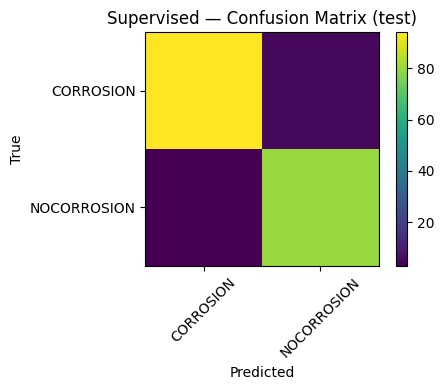

In [12]:
# Supervised — ID test accuracy
_, sup_test_acc = eval_one_epoch(sup_model, test_dl_eval, sup_criterion, DEVICE)
print(f'Supervised ID test accuracy: {sup_test_acc:.4f}')

sup_model.eval()
sup_test_preds, sup_test_labels = [], []
with torch.no_grad():
    for images, labels in test_dl_eval:
        logits = sup_model(images.to(DEVICE))
        sup_test_preds.extend(logits.argmax(1).cpu().numpy())
        sup_test_labels.extend(labels.numpy())
print(classification_report(sup_test_labels, sup_test_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(confusion_matrix(sup_test_labels, sup_test_preds), CLASS_NAMES, 'Supervised — Confusion Matrix (test)')

In [13]:
# Supervised — OOD detection

# Softmax scores
sup_softmax_test, sup_softmax_tood = [], []
with torch.no_grad():
    for images, _ in test_dl_eval:
        sup_softmax_test.append(F.softmax(sup_model(images.to(DEVICE)), dim=1).cpu())
    for images, _ in test_ood_dl:
        sup_softmax_tood.append(F.softmax(sup_model(images.to(DEVICE)), dim=1).cpu())
sup_softmax_test = torch.cat(sup_softmax_test)
sup_softmax_tood = torch.cat(sup_softmax_tood)
sup_score_test       = sup_softmax_test.max(dim=1).values.numpy()
sup_score_tood       = sup_softmax_tood.max(dim=1).values.numpy()
sup_corr_prob_tood   = sup_softmax_tood[:, CORROSION_IDX].numpy()
sup_ood_as_corr      = (sup_softmax_tood.argmax(1).numpy() == CORROSION_IDX).mean()

# Feature scores
proto_sup      = l2_normalize_torch(compute_class_prototypes(H_sup_train_l2, y_train, NUM_CLASSES))
sup_feat_test  = cosine_confidence_scores(H_sup_test_l2, proto_sup)
sup_feat_tood  = cosine_confidence_scores(H_sup_tood_l2, proto_sup)

# AUROC
auroc_sup_softmax = compute_auroc(sup_score_test,       sup_score_tood)
auroc_sup_feat    = compute_auroc(sup_feat_test.numpy(), sup_feat_tood.numpy())
print(f'Supervised softmax — ID mean={sup_score_test.mean():.4f}, OOD mean={sup_score_tood.mean():.4f}')
print(f'Supervised feature — ID mean={sup_feat_test.mean():.4f}, OOD mean={sup_feat_tood.mean():.4f}')
print(f'Softmax AUROC: {auroc_sup_softmax:.4f} | Feature AUROC: {auroc_sup_feat:.4f}')
print(f'% OOD as CORROSION: {sup_ood_as_corr*100:.1f}%')

# threshold tuning + final eval
thresh_df_sup = tune_threshold(H_sup_val_l2, y_val_np, H_sup_vood_l2, proto_sup)
t_sup         = best_threshold(thresh_df_sup)
res_sup       = eval_ood_final(H_sup_test_l2, y_test_np, H_sup_tood_l2, proto_sup, t_sup, 'Supervised')

Supervised softmax — ID mean=0.9725, OOD mean=0.9288
Supervised feature — ID mean=0.8169, OOD mean=0.7147
Softmax AUROC: 0.6852 | Feature AUROC: 0.8302
% OOD as CORROSION: 61.5%

  Supervised
  Feature AUROC (ID vs OOD): 0.8302
  Threshold:                 0.7434
  ID coverage:               0.8352
  Accepted ID accuracy:      0.9868
  OOD reject rate:           0.6376


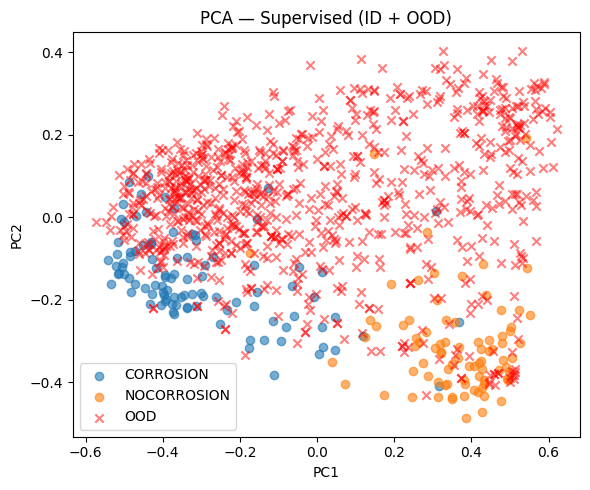

In [14]:
# Supervised — PCA visualisation (ID + OOD)
visualize_feature_space(H_sup_test_l2, y_test_np, H_sup_tood_l2, CLASS_NAMES, 'PCA — Supervised (ID + OOD)')

---
## Section 2 — SimCLR
Self-supervised contrastive learning. NT-Xent loss (temp=0.07), Adam lr=3e-4, CosineAnnealingLR, 50 epochs.
Linear probe on frozen 512-dim backbone features.

In [15]:
# SimCLR — model and loss

class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])  # [B, 512, 1, 1]
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim), nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        return h, F.normalize(self.projector(h), dim=1)


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temp = temperature

    def forward(self, z1, z2):
        N   = z1.size(0)
        z   = torch.cat([z1, z2], dim=0)
        sim = torch.mm(z, z.T) / self.temp
        logits_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim = sim - logits_max.detach()
        pos  = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)])
        mask = ~torch.eye(2 * N, dtype=torch.bool, device=z.device)
        mask[torch.arange(N), torch.arange(N) + N] = False
        mask[torch.arange(N) + N, torch.arange(N)] = False
        neg    = sim[mask].view(2 * N, -1)
        logits = torch.cat([pos.unsqueeze(1), neg], dim=1)
        labels = torch.zeros(2 * N, dtype=torch.long, device=z.device)
        return F.cross_entropy(logits, labels)


def train_simclr_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for view_list, _ in dataloader:
        view1, view2 = view_list[0].to(device), view_list[1].to(device)
        optimizer.zero_grad()
        _, z1 = model(view1); _, z2 = model(view2)
        loss  = criterion(z1, z2)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * view1.size(0)
    return running_loss / len(dataloader.dataset)


def fit_simclr(model, dataloader, criterion, optimizer, scheduler, device,
               epochs=50, checkpoint_path=None):
    history    = {'train_loss': []}
    best_loss, best_state = float('inf'), None
    for epoch in range(epochs):
        loss = train_simclr_one_epoch(model, dataloader, criterion, optimizer, device)
        scheduler.step()
        history['train_loss'].append(loss)
        print(f'Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.6f}')
        if loss < best_loss:
            best_loss, best_state = loss, deepcopy(model.state_dict())
            if checkpoint_path: torch.save(best_state, checkpoint_path)
    if best_state: model.load_state_dict(best_state)
    return model, history, best_loss


simclr_model = SimCLR(proj_dim=SIMCLR_PROJ_DIM).to(DEVICE)
print(f'SimCLR trainable params: {sum(p.numel() for p in simclr_model.parameters() if p.requires_grad):,}')

SimCLR trainable params: 11,504,832


Epoch 01/50 | loss=1.7901 | lr=0.000300
Epoch 02/50 | loss=0.8667 | lr=0.000299
Epoch 03/50 | loss=0.6696 | lr=0.000297
Epoch 04/50 | loss=0.5548 | lr=0.000295
Epoch 05/50 | loss=0.4795 | lr=0.000293
Epoch 06/50 | loss=0.4054 | lr=0.000289
Epoch 07/50 | loss=0.3916 | lr=0.000286
Epoch 08/50 | loss=0.3977 | lr=0.000281
Epoch 09/50 | loss=0.3470 | lr=0.000277
Epoch 10/50 | loss=0.3407 | lr=0.000271
Epoch 11/50 | loss=0.3130 | lr=0.000266
Epoch 12/50 | loss=0.2796 | lr=0.000259
Epoch 13/50 | loss=0.2504 | lr=0.000253
Epoch 14/50 | loss=0.2577 | lr=0.000246
Epoch 15/50 | loss=0.2367 | lr=0.000238
Epoch 16/50 | loss=0.2396 | lr=0.000230
Epoch 17/50 | loss=0.2206 | lr=0.000222
Epoch 18/50 | loss=0.2076 | lr=0.000214
Epoch 19/50 | loss=0.2080 | lr=0.000205
Epoch 20/50 | loss=0.2081 | lr=0.000196
Epoch 21/50 | loss=0.1913 | lr=0.000187
Epoch 22/50 | loss=0.1935 | lr=0.000178
Epoch 23/50 | loss=0.2010 | lr=0.000169
Epoch 24/50 | loss=0.1858 | lr=0.000159
Epoch 25/50 | loss=0.1704 | lr=0.000150


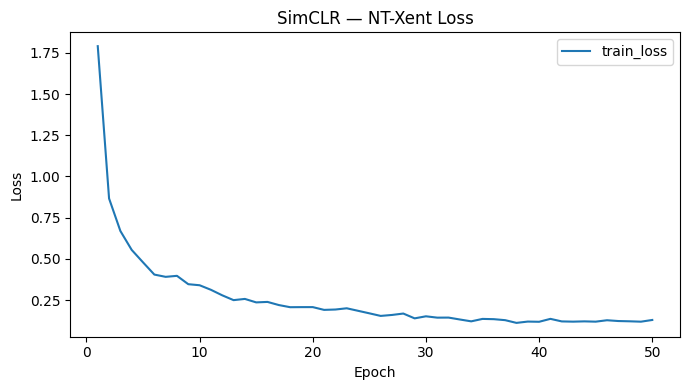

In [16]:
# Train SimCLR
simclr_criterion = NTXentLoss(temperature=SIMCLR_TEMP)
simclr_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=SIMCLR_LR, weight_decay=1e-4)
simclr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(simclr_optimizer, T_max=SIMCLR_EPOCHS, eta_min=0)

simclr_model, simclr_history, simclr_best_loss = fit_simclr(
    simclr_model, train_dl_simclr, simclr_criterion,
    simclr_optimizer, simclr_scheduler,
    DEVICE, epochs=SIMCLR_EPOCHS, checkpoint_path='simclr_best.pt'
)
print(f'\nBest SimCLR loss: {simclr_best_loss:.4f}')
plot_training_history(simclr_history, 'SimCLR — NT-Xent Loss')

In [17]:
# extract SimCLR features (h vector 512-dim)
H_simclr_train, _, _ = extract_embeddings_contrastive(simclr_model, train_dl_eval, DEVICE)
H_simclr_val,   _, _ = extract_embeddings_contrastive(simclr_model, val_dl_eval,   DEVICE)
H_simclr_test,  _, _ = extract_embeddings_contrastive(simclr_model, test_dl_eval,  DEVICE)
H_simclr_vood,  _, _ = extract_embeddings_contrastive(simclr_model, val_ood_dl,    DEVICE)
H_simclr_tood,  _, _ = extract_embeddings_contrastive(simclr_model, test_ood_dl,   DEVICE)

H_simclr_train_l2 = l2_normalize_torch(H_simclr_train)
H_simclr_val_l2   = l2_normalize_torch(H_simclr_val)
H_simclr_test_l2  = l2_normalize_torch(H_simclr_test)
H_simclr_vood_l2  = l2_normalize_torch(H_simclr_vood)
H_simclr_tood_l2  = l2_normalize_torch(H_simclr_tood)
print(f'SimCLR features: train={H_simclr_train.shape}, test={H_simclr_test.shape}')

SimCLR features: train=torch.Size([2522, 512]), test=torch.Size([182, 512])


SimCLR linear probe — train=0.8929 | val=0.8315 | test=0.8736
              precision    recall  f1-score   support

   CORROSION       0.90      0.86      0.88        99
 NOCORROSION       0.84      0.89      0.87        83

    accuracy                           0.87       182
   macro avg       0.87      0.88      0.87       182
weighted avg       0.88      0.87      0.87       182



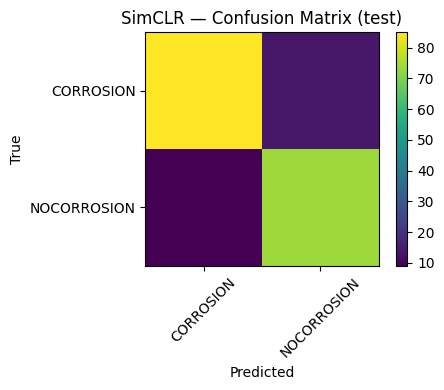

In [18]:
# SimCLR — linear probe + ID accuracy
simclr_probe_clf, simclr_train_acc, simclr_val_acc = run_linear_probe(
    H_simclr_train_l2, y_train, H_simclr_val_l2, y_val
)
simclr_test_preds = simclr_probe_clf.predict(H_simclr_test_l2.numpy())
simclr_test_acc   = accuracy_score(y_test.numpy(), simclr_test_preds)
print(f'SimCLR linear probe — train={simclr_train_acc:.4f} | val={simclr_val_acc:.4f} | test={simclr_test_acc:.4f}')
print(classification_report(y_test.numpy(), simclr_test_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(confusion_matrix(y_test.numpy(), simclr_test_preds), CLASS_NAMES, 'SimCLR — Confusion Matrix (test)')

In [19]:
# SimCLR — OOD detection

# Softmax scores from linear probe
simclr_prob_test     = simclr_probe_clf.predict_proba(H_simclr_test_l2.numpy())
simclr_prob_tood     = simclr_probe_clf.predict_proba(H_simclr_tood_l2.numpy())
simclr_score_test    = simclr_prob_test.max(axis=1)
simclr_score_tood    = simclr_prob_tood.max(axis=1)
simclr_corr_prob_tood = simclr_prob_tood[:, CORROSION_IDX]
simclr_ood_preds     = simclr_probe_clf.predict(H_simclr_tood_l2.numpy())
simclr_ood_as_corr   = (simclr_ood_preds == CORROSION_IDX).mean()

# Feature scores
proto_simclr      = l2_normalize_torch(compute_class_prototypes(H_simclr_train_l2, y_train, NUM_CLASSES))
simclr_feat_test  = cosine_confidence_scores(H_simclr_test_l2, proto_simclr)
simclr_feat_tood  = cosine_confidence_scores(H_simclr_tood_l2, proto_simclr)

# AUROC
auroc_simclr_softmax = compute_auroc(simclr_score_test,       simclr_score_tood)
auroc_simclr_feat    = compute_auroc(simclr_feat_test.numpy(), simclr_feat_tood.numpy())
print(f'SimCLR softmax — ID mean={simclr_score_test.mean():.4f}, OOD mean={simclr_score_tood.mean():.4f}')
print(f'SimCLR feature — ID mean={simclr_feat_test.mean():.4f}, OOD mean={simclr_feat_tood.mean():.4f}')
print(f'Softmax AUROC: {auroc_simclr_softmax:.4f} | Feature AUROC: {auroc_simclr_feat:.4f}')
print(f'% OOD as CORROSION: {simclr_ood_as_corr*100:.1f}%')

# Threshold tuning + final eval
thresh_df_simclr = tune_threshold(H_simclr_val_l2, y_val_np, H_simclr_vood_l2, proto_simclr)
t_simclr         = best_threshold(thresh_df_simclr)
res_simclr       = eval_ood_final(H_simclr_test_l2, y_test_np, H_simclr_tood_l2, proto_simclr, t_simclr, 'SimCLR')

SimCLR softmax — ID mean=0.8077, OOD mean=0.7391
SimCLR feature — ID mean=0.7329, OOD mean=0.6501
Softmax AUROC: 0.6480 | Feature AUROC: 0.8391
% OOD as CORROSION: 54.0%

  SimCLR
  Feature AUROC (ID vs OOD): 0.8391
  Threshold:                 0.6870
  ID coverage:               0.8516
  Accepted ID accuracy:      0.8710
  OOD reject rate:           0.6788


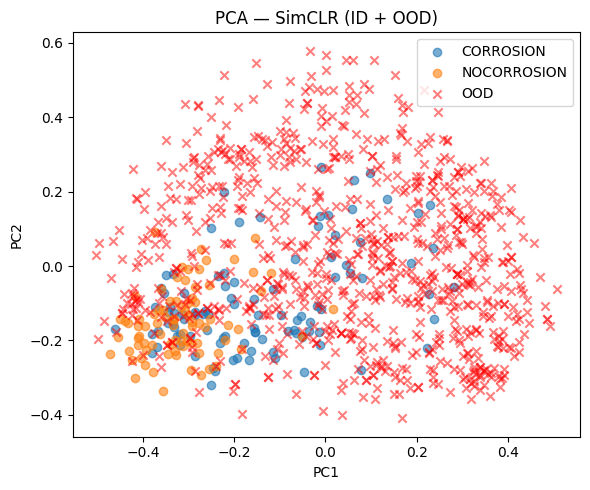

In [20]:
visualize_feature_space(H_simclr_test_l2, y_test_np, H_simclr_tood_l2, CLASS_NAMES, 'PCA — SimCLR (ID + OOD)')

---
## Section 3 — SupCon (Supervised Contrastive)
Supervised contrastive loss (temp=0.1), SGD momentum=0.9, lr=0.125, CosineAnnealingLR, 50 epochs.
Linear probe on frozen 512-dim backbone features.

In [21]:
# SupCon — model and loss

class ResNet18SupCon(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim), nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        return h, F.normalize(self.projector(h), dim=1)


class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temp = temperature

    def forward(self, features, labels):
        """features: [B, 2, D], labels: [B]"""
        device = features.device
        B      = features.shape[0]
        f      = F.normalize(torch.cat(torch.unbind(features, dim=1), dim=0), dim=1)  # [2B, D]
        labels = labels.repeat(2)
        sim    = torch.mm(f, f.T) / self.temp
        logits_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim = sim - logits_max.detach()
        labels_eq = labels.unsqueeze(0) == labels.unsqueeze(1)
        self_mask = ~torch.eye(2 * B, dtype=torch.bool, device=device)
        pos_mask  = labels_eq & self_mask
        exp_sim   = torch.exp(sim) * self_mask
        log_prob  = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)
        mean_log_prob_pos = (pos_mask * log_prob).sum(1) / (pos_mask.sum(1) + 1e-12)
        return -mean_log_prob_pos.mean()


def train_supcon_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for view_list, labels in dataloader:
        view1, view2 = view_list[0].to(device), view_list[1].to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        _, z1 = model(view1); _, z2 = model(view2)
        features = torch.stack([z1, z2], dim=1)
        loss     = criterion(features, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * view1.size(0)
    return running_loss / len(dataloader.dataset)


def fit_supcon(model, dataloader, criterion, optimizer, scheduler, device,
               epochs=50, checkpoint_path=None):
    history    = {'train_loss': []}
    best_loss, best_state = float('inf'), None
    for epoch in range(epochs):
        loss = train_supcon_one_epoch(model, dataloader, criterion, optimizer, device)
        scheduler.step()
        history['train_loss'].append(loss)
        print(f'Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.5f}')
        if loss < best_loss:
            best_loss, best_state = loss, deepcopy(model.state_dict())
            if checkpoint_path: torch.save(best_state, checkpoint_path)
    if best_state: model.load_state_dict(best_state)
    return model, history, best_loss


supcon_model = ResNet18SupCon(proj_dim=SUPCON_PROJ_DIM).to(DEVICE)
print(f'SupCon trainable params: {sum(p.numel() for p in supcon_model.parameters() if p.requires_grad):,}')

SupCon trainable params: 11,504,832


Epoch 01/50 | loss=5.6272 | lr=0.12488
Epoch 02/50 | loss=5.4743 | lr=0.12451
Epoch 03/50 | loss=5.4530 | lr=0.12389
Epoch 04/50 | loss=5.4391 | lr=0.12304
Epoch 05/50 | loss=5.4129 | lr=0.12194
Epoch 06/50 | loss=5.3801 | lr=0.12061
Epoch 07/50 | loss=5.3787 | lr=0.11905
Epoch 08/50 | loss=5.3593 | lr=0.11727
Epoch 09/50 | loss=5.3443 | lr=0.11527
Epoch 10/50 | loss=5.3516 | lr=0.11306
Epoch 11/50 | loss=5.3216 | lr=0.11066
Epoch 12/50 | loss=5.2955 | lr=0.10806
Epoch 13/50 | loss=5.2890 | lr=0.10528
Epoch 14/50 | loss=5.3116 | lr=0.10234
Epoch 15/50 | loss=5.2795 | lr=0.09924
Epoch 16/50 | loss=5.2787 | lr=0.09599
Epoch 17/50 | loss=5.2779 | lr=0.09261
Epoch 18/50 | loss=5.2390 | lr=0.08911
Epoch 19/50 | loss=5.2276 | lr=0.08551
Epoch 20/50 | loss=5.2341 | lr=0.08181
Epoch 21/50 | loss=5.2380 | lr=0.07804
Epoch 22/50 | loss=5.2308 | lr=0.07421
Epoch 23/50 | loss=5.1998 | lr=0.07033
Epoch 24/50 | loss=5.2169 | lr=0.06642
Epoch 25/50 | loss=5.1870 | lr=0.06250
Epoch 26/50 | loss=5.1859

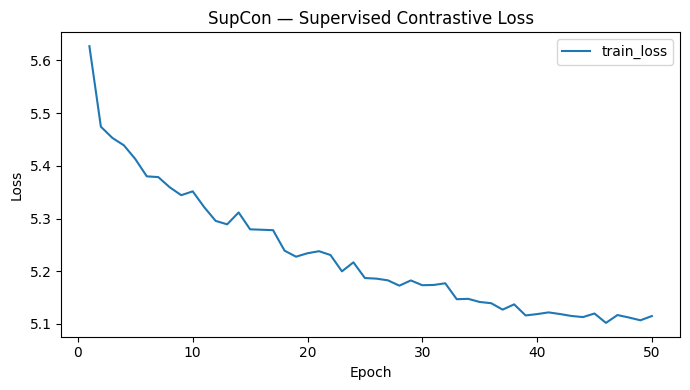

In [22]:
# SupCon training
supcon_criterion = SupConLoss(temperature=SUPCON_TEMP)
supcon_optimizer = torch.optim.SGD(supcon_model.parameters(), lr=SUPCON_LR, momentum=0.9, weight_decay=1e-4)
supcon_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(supcon_optimizer, T_max=SUPCON_EPOCHS)

supcon_model, supcon_history, supcon_best_loss = fit_supcon(
    supcon_model, train_dl_twocrop, supcon_criterion,
    supcon_optimizer, supcon_scheduler,
    DEVICE, epochs=SUPCON_EPOCHS, checkpoint_path='supcon_best.pt'
)
print(f'\nBest SupCon loss: {supcon_best_loss:.4f}')
plot_training_history(supcon_history, 'SupCon — Supervised Contrastive Loss')

In [23]:
# extract SupCon features (same as SimCLR)
H_supcon_train, _, _ = extract_embeddings_contrastive(supcon_model, train_dl_eval, DEVICE)
H_supcon_val,   _, _ = extract_embeddings_contrastive(supcon_model, val_dl_eval,   DEVICE)
H_supcon_test,  _, _ = extract_embeddings_contrastive(supcon_model, test_dl_eval,  DEVICE)
H_supcon_vood,  _, _ = extract_embeddings_contrastive(supcon_model, val_ood_dl,    DEVICE)
H_supcon_tood,  _, _ = extract_embeddings_contrastive(supcon_model, test_ood_dl,   DEVICE)

H_supcon_train_l2 = l2_normalize_torch(H_supcon_train)
H_supcon_val_l2   = l2_normalize_torch(H_supcon_val)
H_supcon_test_l2  = l2_normalize_torch(H_supcon_test)
H_supcon_vood_l2  = l2_normalize_torch(H_supcon_vood)
H_supcon_tood_l2  = l2_normalize_torch(H_supcon_tood)
print(f'SupCon features: train={H_supcon_train.shape}, test={H_supcon_test.shape}')

SupCon features: train=torch.Size([2522, 512]), test=torch.Size([182, 512])


SupCon linear probe — train=0.9988 | val=0.8943 | test=0.9341
              precision    recall  f1-score   support

   CORROSION       0.96      0.92      0.94        99
 NOCORROSION       0.91      0.95      0.93        83

    accuracy                           0.93       182
   macro avg       0.93      0.94      0.93       182
weighted avg       0.94      0.93      0.93       182



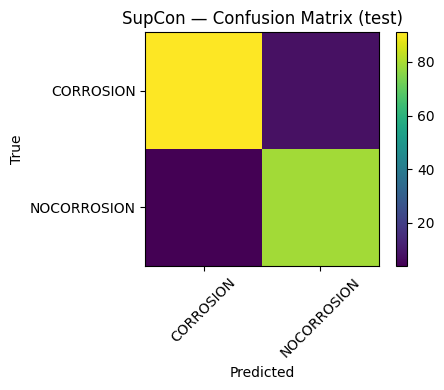

In [24]:
# SupCon — linear probe + ID accuracy
supcon_probe_clf, supcon_train_acc, supcon_val_acc = run_linear_probe(
    H_supcon_train_l2, y_train, H_supcon_val_l2, y_val
)
supcon_test_preds = supcon_probe_clf.predict(H_supcon_test_l2.numpy())
supcon_test_acc   = accuracy_score(y_test.numpy(), supcon_test_preds)
print(f'SupCon linear probe — train={supcon_train_acc:.4f} | val={supcon_val_acc:.4f} | test={supcon_test_acc:.4f}')
print(classification_report(y_test.numpy(), supcon_test_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(confusion_matrix(y_test.numpy(), supcon_test_preds), CLASS_NAMES, 'SupCon — Confusion Matrix (test)')

In [25]:
# SupCon — OOD detection
supcon_prob_test     = supcon_probe_clf.predict_proba(H_supcon_test_l2.numpy())
supcon_prob_tood     = supcon_probe_clf.predict_proba(H_supcon_tood_l2.numpy())
supcon_score_test    = supcon_prob_test.max(axis=1)
supcon_score_tood    = supcon_prob_tood.max(axis=1)
supcon_corr_prob_tood = supcon_prob_tood[:, CORROSION_IDX]
supcon_ood_preds     = supcon_probe_clf.predict(H_supcon_tood_l2.numpy())
supcon_ood_as_corr   = (supcon_ood_preds == CORROSION_IDX).mean()

proto_supcon      = l2_normalize_torch(compute_class_prototypes(H_supcon_train_l2, y_train, NUM_CLASSES))
supcon_feat_test  = cosine_confidence_scores(H_supcon_test_l2, proto_supcon)
supcon_feat_tood  = cosine_confidence_scores(H_supcon_tood_l2, proto_supcon)

auroc_supcon_softmax = compute_auroc(supcon_score_test,       supcon_score_tood)
auroc_supcon_feat    = compute_auroc(supcon_feat_test.numpy(), supcon_feat_tood.numpy())
print(f'SupCon softmax — ID mean={supcon_score_test.mean():.4f}, OOD mean={supcon_score_tood.mean():.4f}')
print(f'SupCon feature — ID mean={supcon_feat_test.mean():.4f}, OOD mean={supcon_feat_tood.mean():.4f}')
print(f'Softmax AUROC: {auroc_supcon_softmax:.4f} | Feature AUROC: {auroc_supcon_feat:.4f}')
print(f'% OOD as CORROSION: {supcon_ood_as_corr*100:.1f}%')

thresh_df_supcon = tune_threshold(H_supcon_val_l2, y_val_np, H_supcon_vood_l2, proto_supcon)
t_supcon         = best_threshold(thresh_df_supcon)
res_supcon       = eval_ood_final(H_supcon_test_l2, y_test_np, H_supcon_tood_l2, proto_supcon, t_supcon, 'SupCon')

SupCon softmax — ID mean=0.9401, OOD mean=0.8467
SupCon feature — ID mean=0.8051, OOD mean=0.6970
Softmax AUROC: 0.7745 | Feature AUROC: 0.8189
% OOD as CORROSION: 62.2%

  SupCon
  Feature AUROC (ID vs OOD): 0.8189
  Threshold:                 0.7138
  ID coverage:               0.8571
  Accepted ID accuracy:      0.9679
  OOD reject rate:           0.5859


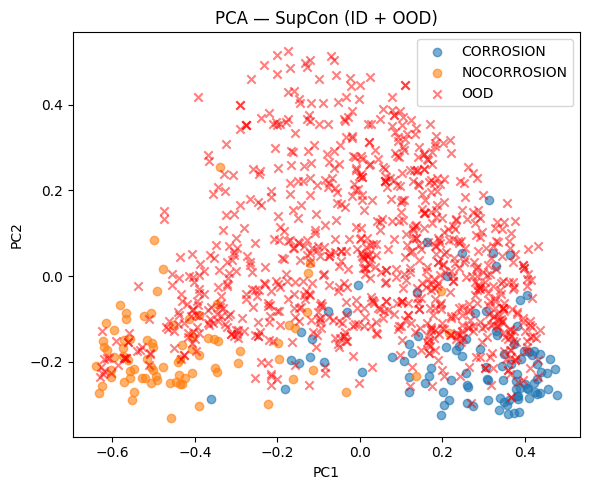

In [26]:
visualize_feature_space(H_supcon_test_l2, y_test_np, H_supcon_tood_l2, CLASS_NAMES, 'PCA — SupCon (ID + OOD)')

---
## Section 4 — BYOL
BYOL. Online+EMA target network, negative cosine similarity loss, Adam lr=3e-4, EMA=0.999, 50 epochs.
Linear probe on frozen 512-dim online encoder backbone features.

In [27]:
# BYOL — architecture and loss

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)


class BYOLEncoder(nn.Module):
    def __init__(self, proj_dim=256, hidden_dim=4096):
        super().__init__()
        base           = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = MLP(self.feat_dim, hidden_dim, proj_dim)

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        return h, self.projector(h)


class BYOL(nn.Module):
    def __init__(self, proj_dim=256, hidden_dim=4096):
        super().__init__()
        self.online_encoder   = BYOLEncoder(proj_dim, hidden_dim)
        self.online_predictor = MLP(proj_dim, hidden_dim, proj_dim)
        self.target_encoder   = BYOLEncoder(proj_dim, hidden_dim)
        self.target_encoder.load_state_dict(self.online_encoder.state_dict())
        for p in self.target_encoder.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update_target(self, decay):
        for p_o, p_t in zip(self.online_encoder.parameters(), self.target_encoder.parameters()):
            p_t.data = decay * p_t.data + (1.0 - decay) * p_o.data

    def forward(self, x1, x2):
        _, z1_o = self.online_encoder(x1); _, z2_o = self.online_encoder(x2)
        q1, q2  = self.online_predictor(z1_o), self.online_predictor(z2_o)
        with torch.no_grad():
            _, z1_t = self.target_encoder(x1); _, z2_t = self.target_encoder(x2)
        return q1, q2, z1_t.detach(), z2_t.detach()

    def get_features(self, x):
        h, _ = self.online_encoder(x)
        return h


def byol_loss(q, z):
    """Negative cosine similarity (bidirectional, range [0,4])."""
    return 2 - 2 * (F.normalize(q, dim=1) * F.normalize(z, dim=1)).sum(dim=1).mean()


def train_byol_one_epoch(model, dataloader, optimizer, device, ema_decay):
    model.train()
    running_loss = 0.0
    for view_list, _ in dataloader:
        x1, x2 = view_list[0].to(device), view_list[1].to(device)
        optimizer.zero_grad()
        q1, q2, z1_t, z2_t = model(x1, x2)
        loss = (byol_loss(q1, z2_t) + byol_loss(q2, z1_t)) * 0.5
        loss.backward(); optimizer.step()
        model.update_target(ema_decay)
        running_loss += loss.item() * x1.size(0)
    return running_loss / len(dataloader.dataset)


def fit_byol(model, dataloader, optimizer, scheduler, device,
             epochs=50, ema_decay=0.996, checkpoint_path=None):
    history    = {'train_loss': []}
    best_loss, best_state = float('inf'), None
    for epoch in range(epochs):
        loss = train_byol_one_epoch(model, dataloader, optimizer, device, ema_decay)
        scheduler.step()
        history['train_loss'].append(loss)
        print(f'Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.6f}')
        if loss < best_loss:
            best_loss, best_state = loss, deepcopy(model.state_dict())
            if checkpoint_path: torch.save(best_state, checkpoint_path)
    if best_state: model.load_state_dict(best_state)
    return model, history, best_loss


byol_model = BYOL(proj_dim=BYOL_PROJ_DIM, hidden_dim=BYOL_HIDDEN).to(DEVICE)
print(f'BYOL trainable params: {sum(p.numel() for p in byol_model.parameters() if p.requires_grad):,}')

BYOL trainable params: 11,835,456


In [28]:
# retrain, veriffy the hyperparametr
print(BYOL_EMA_DECAY)
print(BYOL_BATCH)

0.999
128


Epoch 01/80 | loss=1.0873 | lr=0.000300
Epoch 02/80 | loss=0.7033 | lr=0.000300
Epoch 03/80 | loss=0.6504 | lr=0.000299
Epoch 04/80 | loss=0.6212 | lr=0.000298
Epoch 05/80 | loss=0.5968 | lr=0.000297
Epoch 06/80 | loss=0.5785 | lr=0.000296
Epoch 07/80 | loss=0.5620 | lr=0.000294
Epoch 08/80 | loss=0.5477 | lr=0.000293
Epoch 09/80 | loss=0.5335 | lr=0.000291
Epoch 10/80 | loss=0.5221 | lr=0.000289
Epoch 11/80 | loss=0.5044 | lr=0.000286
Epoch 12/80 | loss=0.4956 | lr=0.000284
Epoch 13/80 | loss=0.4785 | lr=0.000281
Epoch 14/80 | loss=0.4694 | lr=0.000278
Epoch 15/80 | loss=0.4552 | lr=0.000275
Epoch 16/80 | loss=0.4466 | lr=0.000271
Epoch 17/80 | loss=0.4325 | lr=0.000268
Epoch 18/80 | loss=0.4219 | lr=0.000264
Epoch 19/80 | loss=0.4103 | lr=0.000260
Epoch 20/80 | loss=0.4009 | lr=0.000256
Epoch 21/80 | loss=0.3912 | lr=0.000252
Epoch 22/80 | loss=0.3806 | lr=0.000247
Epoch 23/80 | loss=0.3763 | lr=0.000243
Epoch 24/80 | loss=0.3636 | lr=0.000238
Epoch 25/80 | loss=0.3523 | lr=0.000233


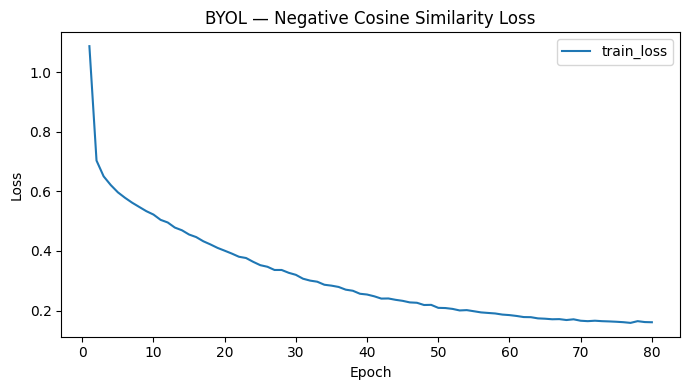

In [29]:
# Train BYOL
byol_optimizer = torch.optim.Adam(
    list(byol_model.online_encoder.parameters()) + list(byol_model.online_predictor.parameters()),
    lr=BYOL_LR, weight_decay=1e-4
)
byol_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(byol_optimizer, T_max=BYOL_EPOCHS, eta_min=0)

byol_model, byol_history, byol_best_loss = fit_byol(
    byol_model, train_dl_byol, byol_optimizer, byol_scheduler,
    DEVICE, epochs=BYOL_EPOCHS, ema_decay=BYOL_EMA_DECAY, checkpoint_path='byol_best.pt'
)
print(f'\nBest BYOL loss: {byol_best_loss:.4f}')
plot_training_history(byol_history, 'BYOL — Negative Cosine Similarity Loss')

In [30]:
# extract BYOL features from online encoder backbone
H_byol_train, _ = extract_byol_features(byol_model, train_dl_eval, DEVICE)
H_byol_val,   _ = extract_byol_features(byol_model, val_dl_eval,   DEVICE)
H_byol_test,  _ = extract_byol_features(byol_model, test_dl_eval,  DEVICE)
H_byol_vood,  _ = extract_byol_features(byol_model, val_ood_dl,    DEVICE)
H_byol_tood,  _ = extract_byol_features(byol_model, test_ood_dl,   DEVICE)

H_byol_train_l2 = l2_normalize_torch(H_byol_train)
H_byol_val_l2   = l2_normalize_torch(H_byol_val)
H_byol_test_l2  = l2_normalize_torch(H_byol_test)
H_byol_vood_l2  = l2_normalize_torch(H_byol_vood)
H_byol_tood_l2  = l2_normalize_torch(H_byol_tood)
print(f'BYOL features: train={H_byol_train.shape}, test={H_byol_test.shape}')

BYOL features: train=torch.Size([2522, 512]), test=torch.Size([182, 512])


BYOL linear probe — train=0.9322 | val=0.8453 | test=0.9341
              precision    recall  f1-score   support

   CORROSION       0.93      0.95      0.94        99
 NOCORROSION       0.94      0.92      0.93        83

    accuracy                           0.93       182
   macro avg       0.93      0.93      0.93       182
weighted avg       0.93      0.93      0.93       182



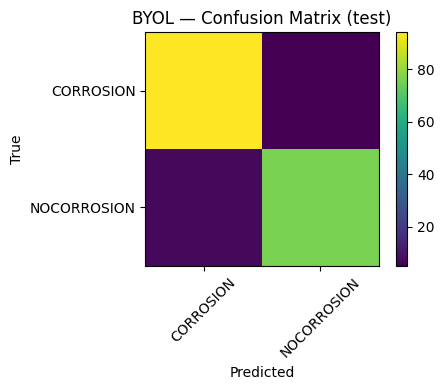

In [31]:
# BYOL — linear probe + ID accuracy
byol_probe_clf, byol_train_acc, byol_val_acc = run_linear_probe(
    H_byol_train_l2, y_train, H_byol_val_l2, y_val
)
byol_test_preds = byol_probe_clf.predict(H_byol_test_l2.numpy())
byol_test_acc   = accuracy_score(y_test.numpy(), byol_test_preds)
print(f'BYOL linear probe — train={byol_train_acc:.4f} | val={byol_val_acc:.4f} | test={byol_test_acc:.4f}')
print(classification_report(y_test.numpy(), byol_test_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(confusion_matrix(y_test.numpy(), byol_test_preds), CLASS_NAMES, 'BYOL — Confusion Matrix (test)')

In [32]:
# BYOL — OOD detection
byol_prob_test      = byol_probe_clf.predict_proba(H_byol_test_l2.numpy())
byol_prob_tood      = byol_probe_clf.predict_proba(H_byol_tood_l2.numpy())
byol_score_test     = byol_prob_test.max(axis=1)
byol_score_tood     = byol_prob_tood.max(axis=1)
byol_corr_prob_tood = byol_prob_tood[:, CORROSION_IDX]
byol_ood_preds      = byol_probe_clf.predict(H_byol_tood_l2.numpy())
byol_ood_as_corr    = (byol_ood_preds == CORROSION_IDX).mean()

proto_byol      = l2_normalize_torch(compute_class_prototypes(H_byol_train_l2, y_train, NUM_CLASSES))
byol_feat_test  = cosine_confidence_scores(H_byol_test_l2, proto_byol)
byol_feat_tood  = cosine_confidence_scores(H_byol_tood_l2, proto_byol)

auroc_byol_softmax = compute_auroc(byol_score_test,       byol_score_tood)
auroc_byol_feat    = compute_auroc(byol_feat_test.numpy(), byol_feat_tood.numpy())
print(f'BYOL softmax — ID mean={byol_score_test.mean():.4f}, OOD mean={byol_score_tood.mean():.4f}')
print(f'BYOL feature — ID mean={byol_feat_test.mean():.4f}, OOD mean={byol_feat_tood.mean():.4f}')
print(f'Softmax AUROC: {auroc_byol_softmax:.4f} | Feature AUROC: {auroc_byol_feat:.4f}')
print(f'% OOD as CORROSION: {byol_ood_as_corr*100:.1f}%')

thresh_df_byol = tune_threshold(H_byol_val_l2, y_val_np, H_byol_vood_l2, proto_byol)
t_byol         = best_threshold(thresh_df_byol)
res_byol       = eval_ood_final(H_byol_test_l2, y_test_np, H_byol_tood_l2, proto_byol, t_byol, 'BYOL')

BYOL softmax — ID mean=0.8448, OOD mean=0.7897
BYOL feature — ID mean=0.7070, OOD mean=0.6456
Softmax AUROC: 0.6208 | Feature AUROC: 0.7569
% OOD as CORROSION: 62.1%

  BYOL
  Feature AUROC (ID vs OOD): 0.7569
  Threshold:                 0.6506
  ID coverage:               0.8681
  Accepted ID accuracy:      0.9367
  OOD reject rate:           0.5412


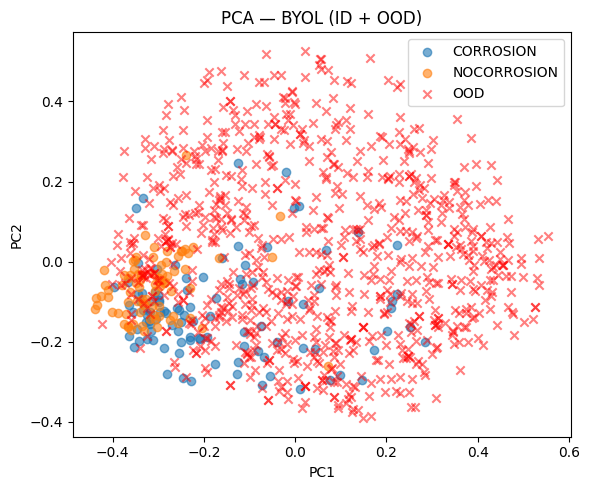

In [33]:
visualize_feature_space(H_byol_test_l2, y_test_np, H_byol_tood_l2, CLASS_NAMES, 'PCA — BYOL (ID + OOD)')

---
## Section 5 — ViT-Base
vit-base-patch16-224, full fine-tuning. AdamW lr=2e-5, CosineAnnealingLR, 10 epochs.
Features: from last transformer layer (768-dim).

In [34]:
# Load ViT-Base with 2-class task head
from transformers import ViTForImageClassification

# ViT-specific dataloaders
train_dl_vit      = DataLoader(datasets.ImageFolder(TRAIN_DIR, transform=train_tf),
                               batch_size=VIT_BATCH, shuffle=True,  num_workers=NUM_WORKERS)
val_dl_vit        = DataLoader(datasets.ImageFolder(VAL_DIR,   transform=eval_tf),
                               batch_size=VIT_BATCH, shuffle=False, num_workers=NUM_WORKERS)
train_dl_vit_eval = DataLoader(datasets.ImageFolder(TRAIN_DIR, transform=eval_tf),
                               batch_size=VIT_BATCH, shuffle=False, num_workers=NUM_WORKERS)

vit_model = ViTForImageClassification.from_pretrained(
    VIT_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True
).to(DEVICE)

print(f'ViT-Base trainable params: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad):,}')

/Users/kuoweitseng/anaconda3/envs/rustai_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 9655.28it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight

ViT-Base trainable params: 85,800,194


Epoch 01/10 | train_loss=0.3605 acc=0.8509 | val_loss=0.2641 acc=0.9005
Epoch 02/10 | train_loss=0.1305 acc=0.9600 | val_loss=0.1823 acc=0.9326
Epoch 03/10 | train_loss=0.0681 acc=0.9802 | val_loss=0.1590 acc=0.9296
Epoch 04/10 | train_loss=0.0416 acc=0.9869 | val_loss=0.1592 acc=0.9311
Epoch 05/10 | train_loss=0.0307 acc=0.9937 | val_loss=0.1644 acc=0.9372
Epoch 06/10 | train_loss=0.0275 acc=0.9921 | val_loss=0.1420 acc=0.9433
Epoch 07/10 | train_loss=0.0137 acc=0.9964 | val_loss=0.1373 acc=0.9464
Epoch 08/10 | train_loss=0.0180 acc=0.9944 | val_loss=0.1478 acc=0.9418
Epoch 09/10 | train_loss=0.0130 acc=0.9956 | val_loss=0.1452 acc=0.9403
Epoch 10/10 | train_loss=0.0166 acc=0.9952 | val_loss=0.1454 acc=0.9387

Best ViT val acc: 0.9464


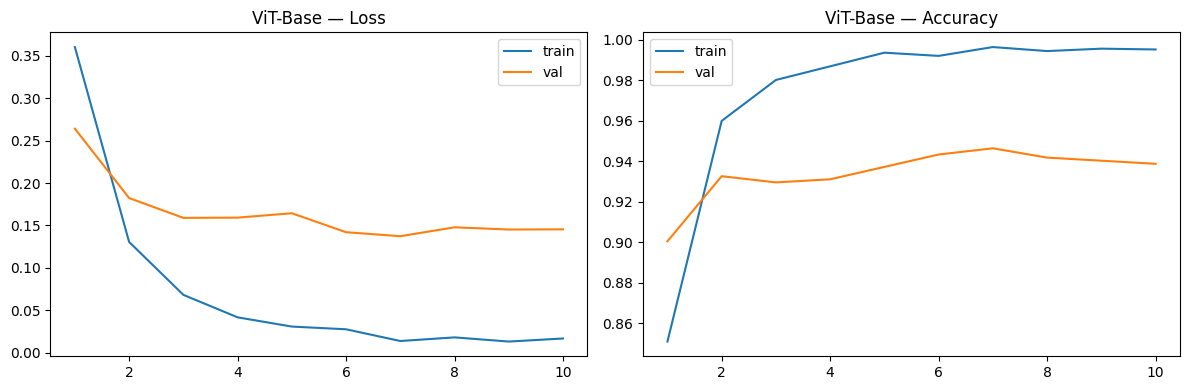

In [35]:
# train ViT

def fit_vit(model, train_dl, val_dl, optimizer, scheduler, device, epochs, checkpoint_path):
    criterion    = nn.CrossEntropyLoss()
    best_val_acc = 0.0
    history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for images, labels in train_dl:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(pixel_values=images)
            loss = criterion(out.logits, labels)
            loss.backward(); optimizer.step()
            t_loss    += loss.item() * images.size(0)
            t_correct += (out.logits.argmax(1) == labels).sum().item()
            t_total   += images.size(0)
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_dl:
                images, labels = images.to(device), labels.to(device)
                out  = model(pixel_values=images)
                loss = criterion(out.logits, labels)
                v_loss    += loss.item() * images.size(0)
                v_correct += (out.logits.argmax(1) == labels).sum().item()
                v_total   += images.size(0)
        tl = t_loss/t_total; ta = t_correct/t_total
        vl = v_loss/v_total; va = v_correct/v_total
        if scheduler: scheduler.step()
        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), checkpoint_path)
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        print(f'Epoch {epoch:02d}/{epochs} | train_loss={tl:.4f} acc={ta:.4f} | val_loss={vl:.4f} acc={va:.4f}')
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f'\nBest ViT val acc: {best_val_acc:.4f}')
    return model, history, best_val_acc


vit_optimizer = torch.optim.AdamW(vit_model.parameters(), lr=VIT_LR, weight_decay=1e-2)
vit_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=VIT_EPOCHS, eta_min=1e-6)

vit_model, vit_history, vit_best_val_acc = fit_vit(
    vit_model, train_dl_vit, val_dl_vit, vit_optimizer, vit_scheduler,
    DEVICE, epochs=VIT_EPOCHS, checkpoint_path='vit_best.pt'
)
plot_training_history(vit_history, 'ViT-Base')

In [36]:
# extract ViT features (768-dim)
H_vit_train, _ = extract_vit_features(vit_model, train_dl_vit_eval, DEVICE)
H_vit_val,   _ = extract_vit_features(vit_model, val_dl_eval,       DEVICE)
H_vit_test,  _ = extract_vit_features(vit_model, test_dl_eval,      DEVICE)
H_vit_vood,  _ = extract_vit_features(vit_model, val_ood_dl,        DEVICE)
H_vit_tood,  _ = extract_vit_features(vit_model, test_ood_dl,       DEVICE)

H_vit_train_l2 = l2_normalize_torch(H_vit_train)
H_vit_val_l2   = l2_normalize_torch(H_vit_val)
H_vit_test_l2  = l2_normalize_torch(H_vit_test)
H_vit_vood_l2  = l2_normalize_torch(H_vit_vood)
H_vit_tood_l2  = l2_normalize_torch(H_vit_tood)
print(f'ViT CLS features: train={H_vit_train.shape}, test={H_vit_test.shape}')

ViT CLS features: train=torch.Size([2522, 768]), test=torch.Size([182, 768])


ViT ID test accuracy: 0.9560
              precision    recall  f1-score   support

   CORROSION       0.99      0.93      0.96        99
 NOCORROSION       0.92      0.99      0.95        83

    accuracy                           0.96       182
   macro avg       0.96      0.96      0.96       182
weighted avg       0.96      0.96      0.96       182



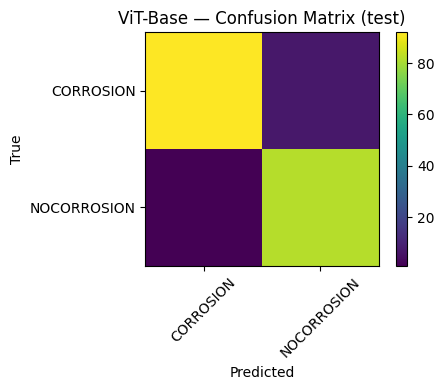

ViT linear probe — train=0.9988 | val=0.9510 | test=0.9615


In [37]:
# ViT — ID test accuracy
vit_model.eval()
vit_test_preds, vit_test_labels = [], []
with torch.no_grad():
    for images, labels in test_dl_eval:
        out = vit_model(pixel_values=images.to(DEVICE))
        vit_test_preds.extend(out.logits.argmax(1).cpu().numpy())
        vit_test_labels.extend(labels.numpy())
vit_test_acc = accuracy_score(vit_test_labels, vit_test_preds)
print(f'ViT ID test accuracy: {vit_test_acc:.4f}')
print(classification_report(vit_test_labels, vit_test_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(confusion_matrix(vit_test_labels, vit_test_preds), CLASS_NAMES, 'ViT-Base — Confusion Matrix (test)')

# ViT linear probe
vit_probe_clf, vit_probe_train_acc, vit_probe_val_acc = run_linear_probe(
    H_vit_train_l2, y_train, H_vit_val_l2, y_val
)
vit_probe_test_acc = accuracy_score(y_test.numpy(), vit_probe_clf.predict(H_vit_test_l2.numpy()))
print(f'ViT linear probe — train={vit_probe_train_acc:.4f} | val={vit_probe_val_acc:.4f} | test={vit_probe_test_acc:.4f}')

In [39]:
# ViT — OOD detection
vit_softmax_test, vit_softmax_tood = [], []
with torch.no_grad():
    for images, _ in test_dl_eval:
        vit_softmax_test.append(F.softmax(vit_model(pixel_values=images.to(DEVICE)).logits, dim=1).cpu())
    for images, _ in test_ood_dl:
        vit_softmax_tood.append(F.softmax(vit_model(pixel_values=images.to(DEVICE)).logits, dim=1).cpu())
vit_softmax_test   = torch.cat(vit_softmax_test)
vit_softmax_tood   = torch.cat(vit_softmax_tood)
vit_score_test     = vit_softmax_test.max(dim=1).values.numpy()
vit_score_tood     = vit_softmax_tood.max(dim=1).values.numpy()
vit_corr_prob_tood = vit_softmax_tood[:, CORROSION_IDX].numpy()
vit_ood_as_corr    = (vit_softmax_tood.argmax(1).numpy() == CORROSION_IDX).mean()

proto_vit      = l2_normalize_torch(compute_class_prototypes(H_vit_train_l2, y_train, NUM_CLASSES))
vit_feat_test  = cosine_confidence_scores(H_vit_test_l2, proto_vit)
vit_feat_tood  = cosine_confidence_scores(H_vit_tood_l2, proto_vit)

auroc_vit_softmax = compute_auroc(vit_score_test,       vit_score_tood)
auroc_vit_feat    = compute_auroc(vit_feat_test.numpy(), vit_feat_tood.numpy())
print(f'ViT softmax — ID mean={vit_score_test.mean():.4f}, OOD mean={vit_score_tood.mean():.4f}')
print(f'ViT feature — ID mean={vit_feat_test.mean():.4f}, OOD mean={vit_feat_tood.mean():.4f}')
print(f'Softmax AUROC: {auroc_vit_softmax:.4f} | Feature AUROC: {auroc_vit_feat:.4f}')
print(f'% OOD as CORROSION: {vit_ood_as_corr*100:.1f}%')

thresh_df_vit = tune_threshold(H_vit_val_l2, y_val_np, H_vit_vood_l2, proto_vit)
t_vit         = best_threshold(thresh_df_vit)
res_vit       = eval_ood_final(H_vit_test_l2, y_test_np, H_vit_tood_l2, proto_vit, t_vit, 'ViT-Base')

ViT softmax — ID mean=0.9751, OOD mean=0.8683
ViT feature — ID mean=0.5710, OOD mean=0.3437
Softmax AUROC: 0.8413 | Feature AUROC: 0.8196
% OOD as CORROSION: 47.1%

  ViT-Base
  Feature AUROC (ID vs OOD): 0.8196
  Threshold:                 0.3116
  ID coverage:               0.9066
  Accepted ID accuracy:      0.9879
  OOD reject rate:           0.4871


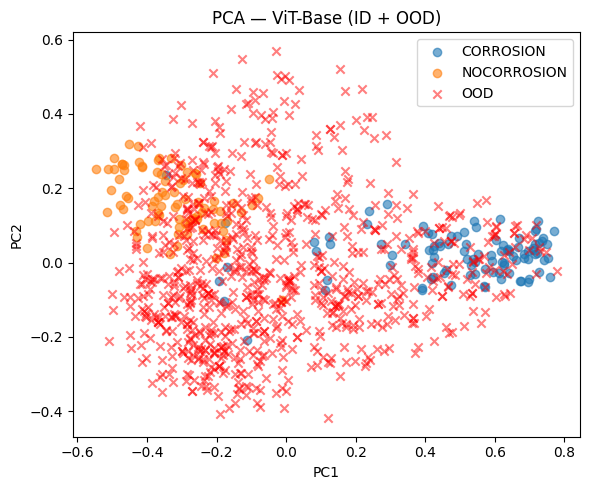

In [40]:
visualize_feature_space(H_vit_test_l2, y_test_np, H_vit_tood_l2, CLASS_NAMES, 'PCA — ViT-Base (ID + OOD)')

---
## Section 6 — Final Comparison
All five methods comparison.

In [41]:
# table — all 5 methods

final_df = pd.DataFrame([
    {'Method': 'Supervised',
     'ID Test Acc':          sup_test_acc,
     'Softmax AUROC':        auroc_sup_softmax,
     'Feature AUROC':        auroc_sup_feat,
     'Cos ID Mean':          float(sup_feat_test.mean()),
     'Cos OOD Mean':         float(sup_feat_tood.mean()),
     'OOD Reject Rate':      res_sup['ood_reject_rate'],
     '% OOD as Corrosion':   sup_ood_as_corr,
     'Mean P(corr) on OOD':  sup_corr_prob_tood.mean()},
    {'Method': 'SimCLR',
     'ID Test Acc':          simclr_test_acc,
     'Softmax AUROC':        auroc_simclr_softmax,
     'Feature AUROC':        auroc_simclr_feat,
     'Cos ID Mean':          float(simclr_feat_test.mean()),
     'Cos OOD Mean':         float(simclr_feat_tood.mean()),
     'OOD Reject Rate':      res_simclr['ood_reject_rate'],
     '% OOD as Corrosion':   simclr_ood_as_corr,
     'Mean P(corr) on OOD':  simclr_corr_prob_tood.mean()},
    {'Method': 'SupCon',
     'ID Test Acc':          supcon_test_acc,
     'Softmax AUROC':        auroc_supcon_softmax,
     'Feature AUROC':        auroc_supcon_feat,
     'Cos ID Mean':          float(supcon_feat_test.mean()),
     'Cos OOD Mean':         float(supcon_feat_tood.mean()),
     'OOD Reject Rate':      res_supcon['ood_reject_rate'],
     '% OOD as Corrosion':   supcon_ood_as_corr,
     'Mean P(corr) on OOD':  supcon_corr_prob_tood.mean()},
    {'Method': 'BYOL',
     'ID Test Acc':          byol_test_acc,
     'Softmax AUROC':        auroc_byol_softmax,
     'Feature AUROC':        auroc_byol_feat,
     'Cos ID Mean':          float(byol_feat_test.mean()),
     'Cos OOD Mean':         float(byol_feat_tood.mean()),
     'OOD Reject Rate':      res_byol['ood_reject_rate'],
     '% OOD as Corrosion':   byol_ood_as_corr,
     'Mean P(corr) on OOD':  byol_corr_prob_tood.mean()},
    {'Method': 'ViT-Base',
     'ID Test Acc':          vit_test_acc,
     'Softmax AUROC':        auroc_vit_softmax,
     'Feature AUROC':        auroc_vit_feat,
     'Cos ID Mean':          float(vit_feat_test.mean()),
     'Cos OOD Mean':         float(vit_feat_tood.mean()),
     'OOD Reject Rate':      res_vit['ood_reject_rate'],
     '% OOD as Corrosion':   vit_ood_as_corr,
     'Mean P(corr) on OOD':  vit_corr_prob_tood.mean()},
]).set_index('Method')

print(final_df.to_string(float_format='{:.4f}'.format))

            ID Test Acc  Softmax AUROC  Feature AUROC  Cos ID Mean  Cos OOD Mean  OOD Reject Rate  % OOD as Corrosion  Mean P(corr) on OOD
Method                                                                                                                                    
Supervised       0.9560         0.6852         0.8302       0.8169        0.7147           0.6376              0.6153               0.6062
SimCLR           0.8736         0.6480         0.8391       0.7329        0.6501           0.6788              0.5400               0.5136
SupCon           0.9341         0.7745         0.8189       0.8051        0.6970           0.5859              0.6224               0.6022
BYOL             0.9341         0.6208         0.7569       0.7070        0.6456           0.5412              0.6212               0.5760
ViT-Base         0.9560         0.8413         0.8196       0.5710        0.3437           0.4871              0.4706               0.4843


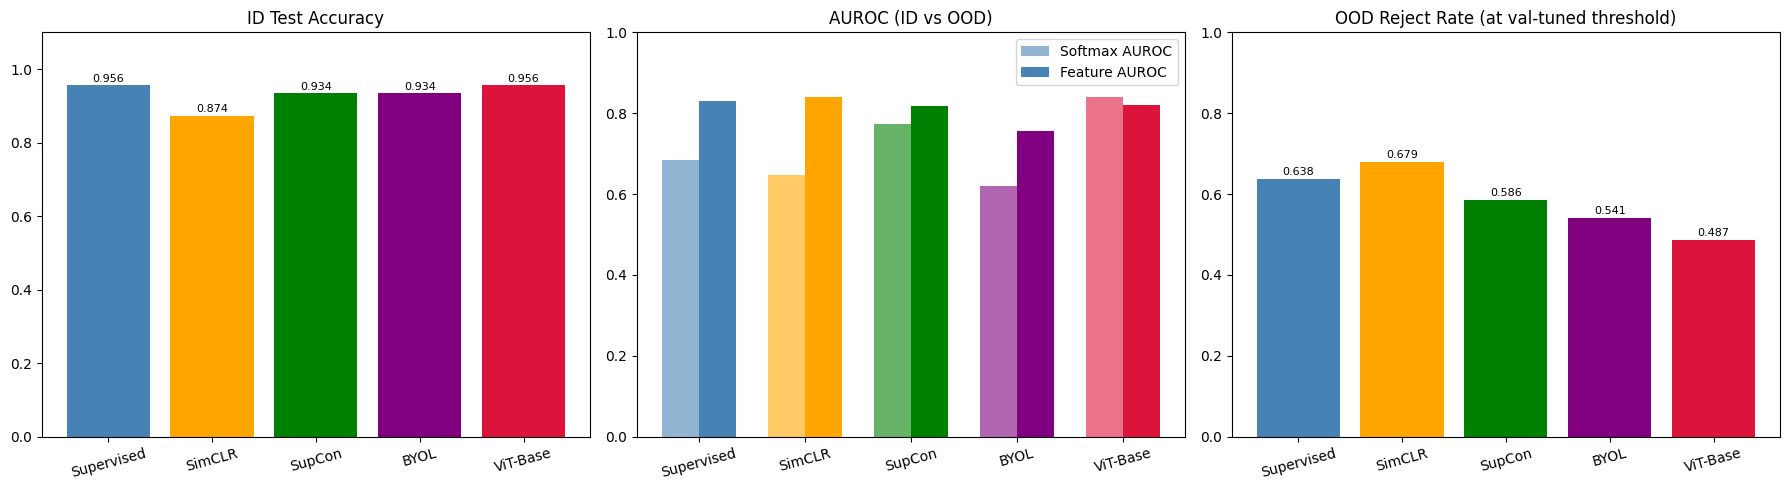

In [42]:
# ID accuracy, AUROC comparison, OOD reject rate

methods = final_df.index.tolist()
colors  = ['steelblue', 'orange', 'green', 'purple', 'crimson']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(methods, final_df['ID Test Acc'], color=colors)
axes[0].set_title('ID Test Accuracy'); axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_df['ID Test Acc']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

x = range(len(methods)); w = 0.35
axes[1].bar([i - w/2 for i in x], final_df['Softmax AUROC'], w, color=colors, alpha=0.6, label='Softmax AUROC')
axes[1].bar([i + w/2 for i in x], final_df['Feature AUROC'],  w, color=colors, alpha=1.0, label='Feature AUROC')
axes[1].set_title('AUROC (ID vs OOD)'); axes[1].set_ylim(0, 1.0)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(methods, rotation=15); axes[1].legend()

axes[2].bar(methods, final_df['OOD Reject Rate'], color=colors)
axes[2].set_title('OOD Reject Rate (at val-tuned threshold)')
axes[2].set_ylim(0, 1.0); axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_df['OOD Reject Rate']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout(); plt.show()

In [43]:
# score gap — cosine similarity ID vs OOD

print(f"{'Method':<15} {'Softmax AUROC':>15} {'Feature AUROC':>15} {'Cos ID':>10} {'Cos OOD':>10} {'Gap':>8}")

for method, id_s, ood_s, s_auroc, f_auroc in [
    ('Supervised', sup_feat_test.numpy(),    sup_feat_tood.numpy(),    auroc_sup_softmax,    auroc_sup_feat),
    ('SimCLR',     simclr_feat_test.numpy(), simclr_feat_tood.numpy(), auroc_simclr_softmax, auroc_simclr_feat),
    ('SupCon',     supcon_feat_test.numpy(), supcon_feat_tood.numpy(), auroc_supcon_softmax, auroc_supcon_feat),
    ('BYOL',       byol_feat_test.numpy(),   byol_feat_tood.numpy(),   auroc_byol_softmax,   auroc_byol_feat),
    ('ViT-Base',   vit_feat_test.numpy(),    vit_feat_tood.numpy(),    auroc_vit_softmax,    auroc_vit_feat),
]:
    id_m, ood_m = id_s.mean(), ood_s.mean()
    print(f'{method:<15} {s_auroc:>15.4f} {f_auroc:>15.4f} {id_m:>10.4f} {ood_m:>10.4f} {id_m-ood_m:>+8.4f}')

Method            Softmax AUROC   Feature AUROC     Cos ID    Cos OOD      Gap
Supervised               0.6852          0.8302     0.8169     0.7147  +0.1022
SimCLR                   0.6480          0.8391     0.7329     0.6501  +0.0828
SupCon                   0.7745          0.8189     0.8051     0.6970  +0.1082
BYOL                     0.6208          0.7569     0.7070     0.6456  +0.0614
ViT-Base                 0.8413          0.8196     0.5710     0.3437  +0.2273


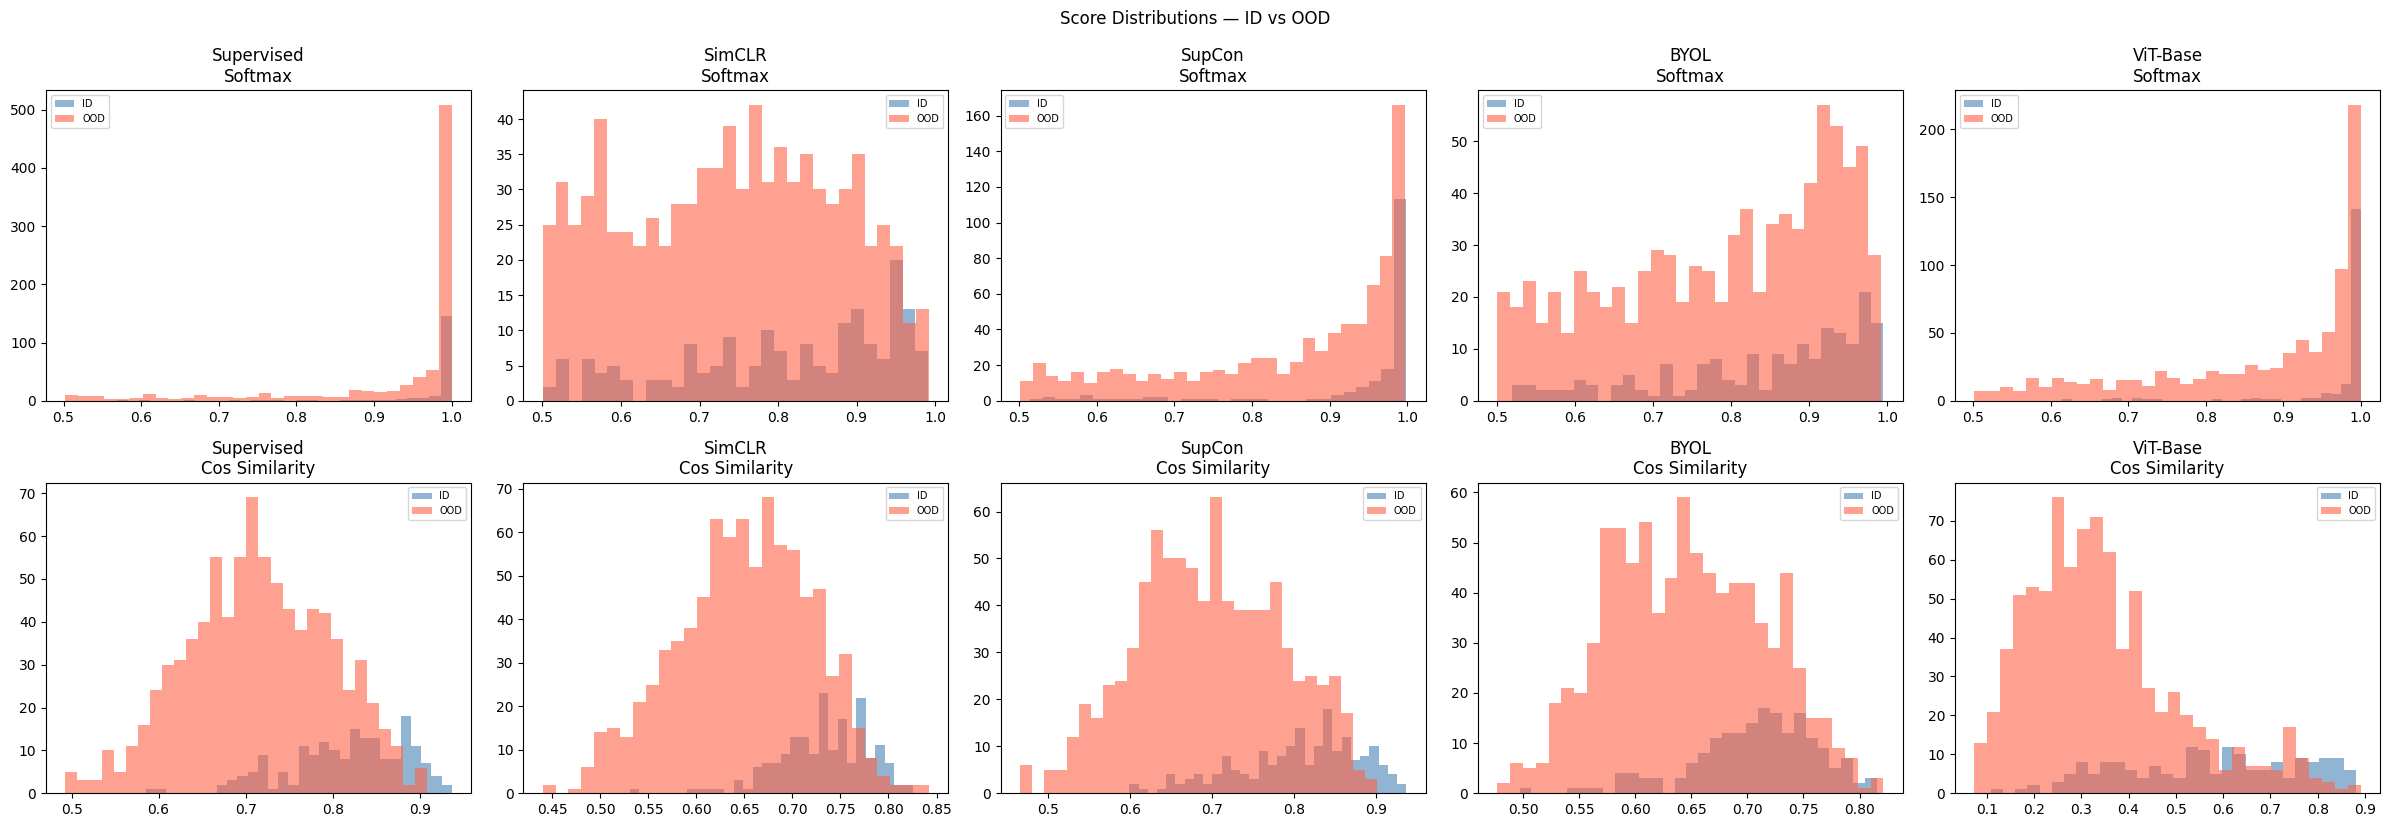

In [44]:
# Score distribution histograms — Softmax and Feature

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
method_data = [
    ('Supervised', sup_score_test,    sup_score_tood,    sup_feat_test.numpy(),    sup_feat_tood.numpy()),
    ('SimCLR',     simclr_score_test, simclr_score_tood, simclr_feat_test.numpy(), simclr_feat_tood.numpy()),
    ('SupCon',     supcon_score_test, supcon_score_tood, supcon_feat_test.numpy(), supcon_feat_tood.numpy()),
    ('BYOL',       byol_score_test,   byol_score_tood,   byol_feat_test.numpy(),   byol_feat_tood.numpy()),
    ('ViT-Base',   vit_score_test,    vit_score_tood,    vit_feat_test.numpy(),    vit_feat_tood.numpy()),
]
for col, (name, sm_id, sm_ood, ft_id, ft_ood) in enumerate(method_data):
    axes[0, col].hist(sm_id,  bins=30, alpha=0.6, color='steelblue', label='ID')
    axes[0, col].hist(sm_ood, bins=30, alpha=0.6, color='tomato',    label='OOD')
    axes[0, col].set_title(f'{name}\nSoftmax'); axes[0, col].legend(fontsize=7)
    axes[1, col].hist(ft_id,  bins=30, alpha=0.6, color='steelblue', label='ID')
    axes[1, col].hist(ft_ood, bins=30, alpha=0.6, color='tomato',    label='OOD')
    axes[1, col].set_title(f'{name}\nCos Similarity'); axes[1, col].legend(fontsize=7)

fig.text(0.5, 1.01, 'Score Distributions — ID vs OOD',
         ha='center', fontsize=12)
plt.tight_layout(); plt.show()

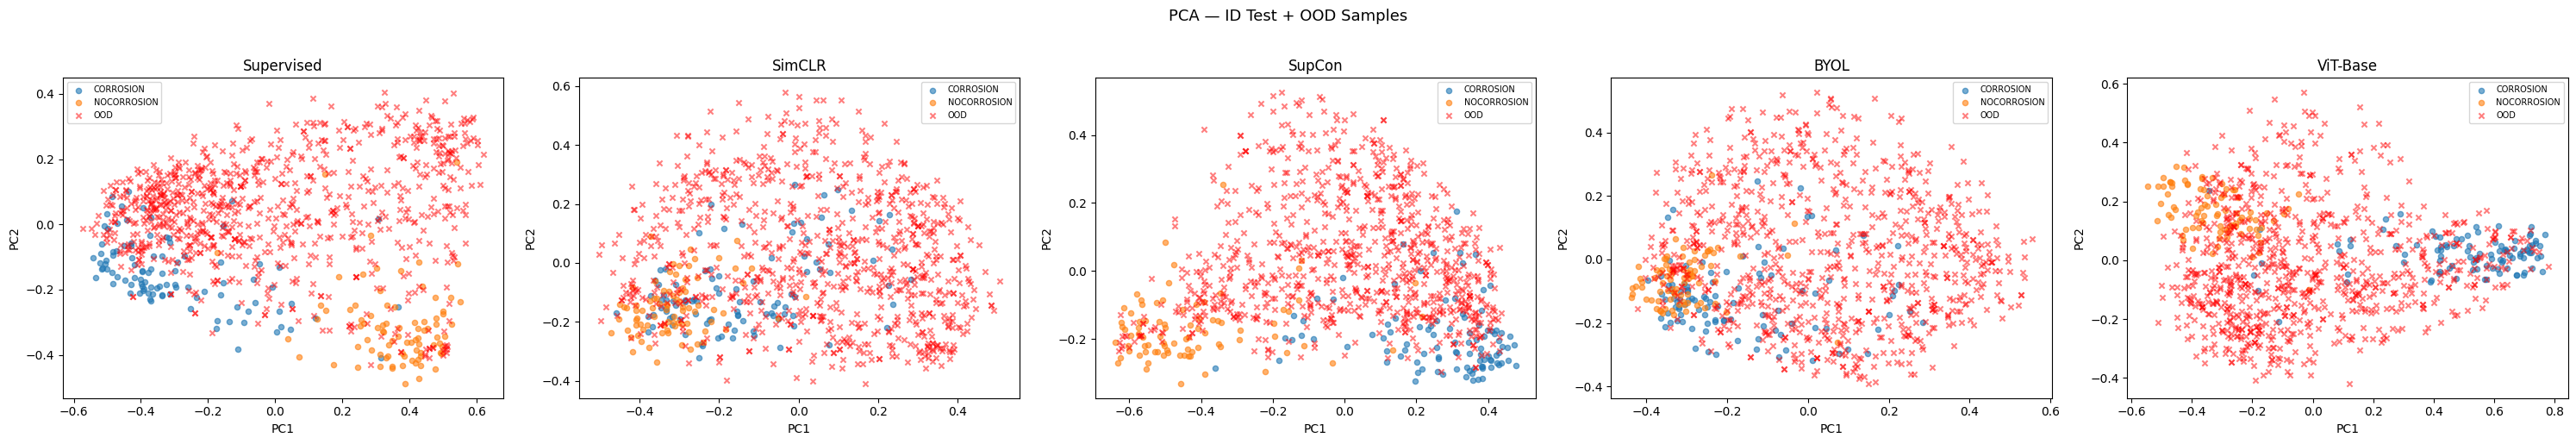

In [45]:
# PCA — all 5 methods (ID + OOD)

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
pca_data = [
    (H_sup_test_l2,    H_sup_tood_l2,    'Supervised'),
    (H_simclr_test_l2, H_simclr_tood_l2, 'SimCLR'),
    (H_supcon_test_l2, H_supcon_tood_l2, 'SupCon'),
    (H_byol_test_l2,   H_byol_tood_l2,   'BYOL'),
    (H_vit_test_l2,    H_vit_tood_l2,    'ViT-Base'),
]
for ax, (H_id, H_ood, name) in zip(axes, pca_data):
    Z_all = np.concatenate([H_id.numpy(), H_ood.numpy()])
    y_all = np.concatenate([y_test_np, np.full(len(H_ood), NUM_CLASSES)])
    Z_2d  = PCA(n_components=2).fit_transform(Z_all)
    for c, cname in enumerate(CLASS_NAMES):
        mask = y_all == c
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], alpha=0.6, label=cname, s=20)
    mask_ood = y_all == NUM_CLASSES
    ax.scatter(Z_2d[mask_ood, 0], Z_2d[mask_ood, 1], alpha=0.5, marker='x', color='red', label='OOD', s=20)
    ax.set_title(name); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7)
plt.suptitle('PCA — ID Test + OOD Samples', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

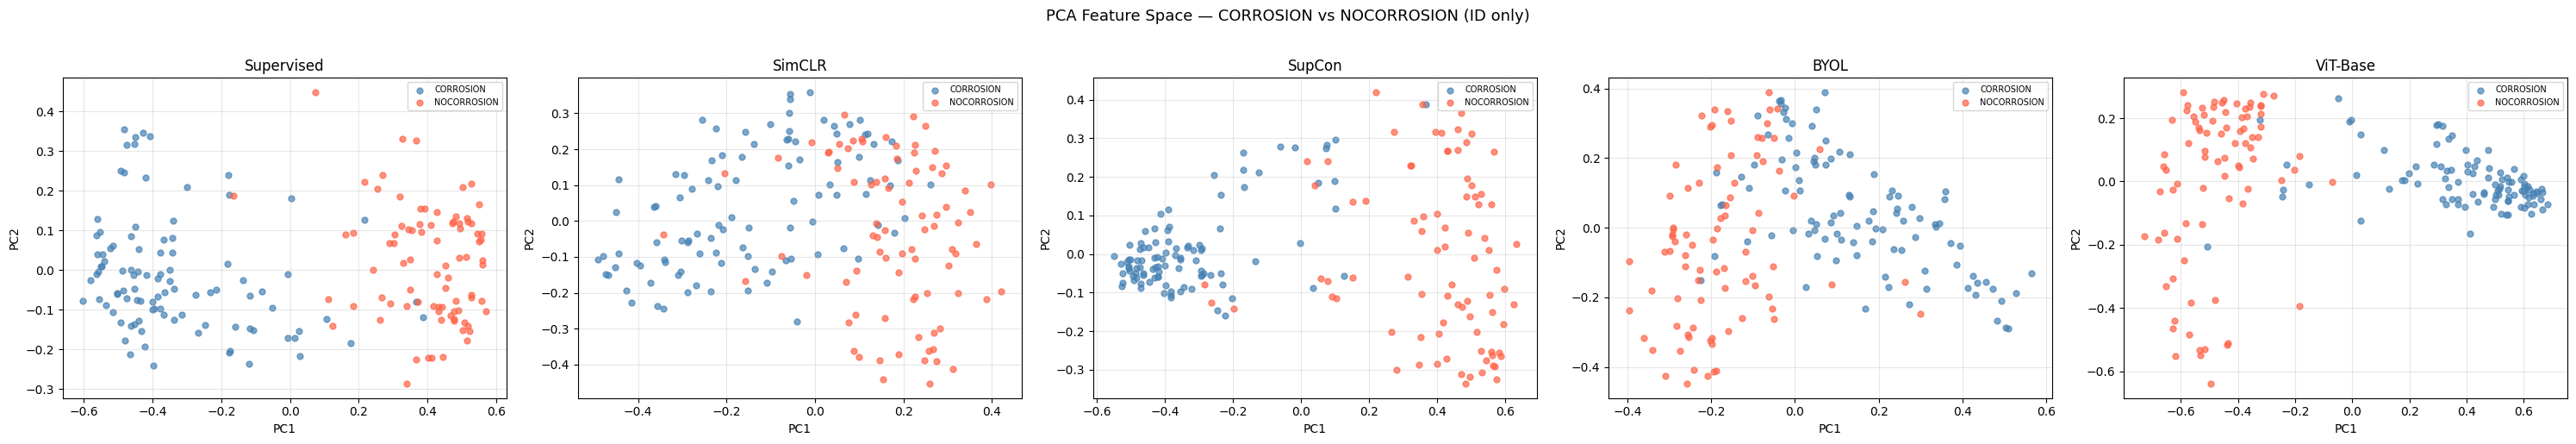

In [48]:
# PCA — ID only 

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
id_pca_data = [
    (H_sup_test_l2,    'Supervised'),
    (H_simclr_test_l2, 'SimCLR'),
    (H_supcon_test_l2, 'SupCon'),
    (H_byol_test_l2,   'BYOL'),
    (H_vit_test_l2,    'ViT-Base'),
]
id_colors = ['steelblue', 'tomato']
for ax, (H, name) in zip(axes, id_pca_data):
    Z_2d = PCA(n_components=2).fit_transform(H.numpy())
    for cls_idx, (cls_name, color) in enumerate(zip(CLASS_NAMES, id_colors)):
        mask = y_test_np == cls_idx
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], c=color, label=cls_name, alpha=0.7, s=25)
    ax.set_title(name); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('PCA Feature Space — CORROSION vs NOCORROSION (ID only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pca_id_separation.png', dpi=150, bbox_inches='tight')
plt.show()

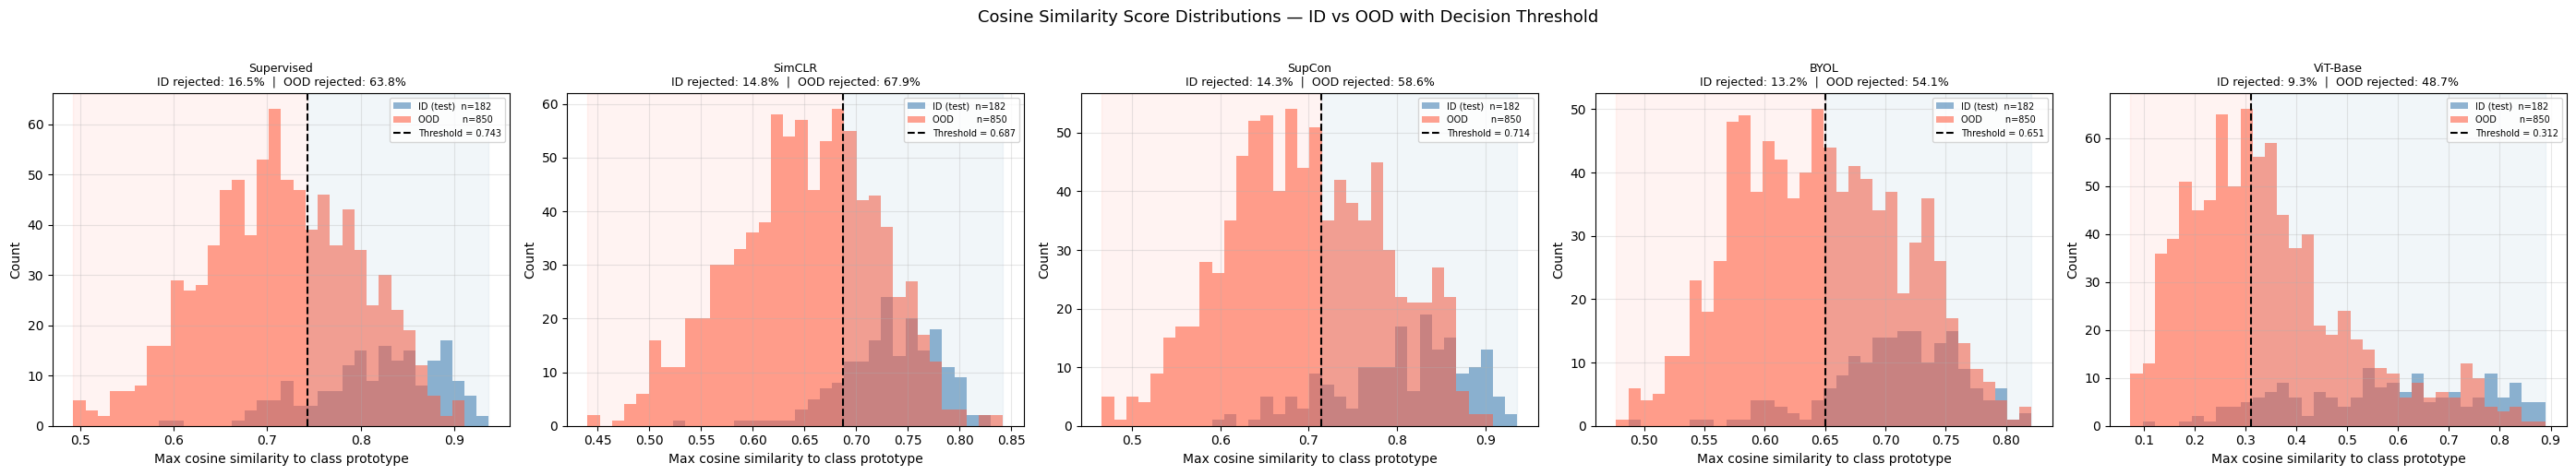

In [49]:
# cosine similarity distributions with threshold

fig, axes = plt.subplots(1, 5, figsize=(28, 5))

cos_data = [
    ('Supervised', sup_feat_test.numpy(),    sup_feat_tood.numpy(),    t_sup),
    ('SimCLR',     simclr_feat_test.numpy(), simclr_feat_tood.numpy(), t_simclr),
    ('SupCon',     supcon_feat_test.numpy(), supcon_feat_tood.numpy(), t_supcon),
    ('BYOL',       byol_feat_test.numpy(),   byol_feat_tood.numpy(),   t_byol),
    ('ViT-Base',   vit_feat_test.numpy(),    vit_feat_tood.numpy(),    t_vit),
]

for ax, (name, id_scores, ood_scores, threshold) in zip(axes, cos_data):
    all_scores = np.concatenate([id_scores, ood_scores])
    bins = np.linspace(all_scores.min(), all_scores.max(), 35)

    ax.hist(id_scores,  bins=bins, alpha=0.6, color='steelblue', label=f'ID (test)  n={len(id_scores)}')
    ax.hist(ood_scores, bins=bins, alpha=0.6, color='tomato',    label=f'OOD        n={len(ood_scores)}')

    ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
               label=f'Threshold = {threshold:.3f}')

    # shade region
    ax.axvspan(threshold, all_scores.max(), alpha=0.07, color='steelblue')
    ax.axvspan(all_scores.min(), threshold, alpha=0.07, color='tomato')

    id_rej  = (id_scores  < threshold).mean()
    ood_rej = (ood_scores < threshold).mean()
    ax.set_title(f'{name}\nID rejected: {id_rej*100:.1f}%  |  OOD rejected: {ood_rej*100:.1f}%',
                 fontsize=9)
    ax.set_xlabel('Max cosine similarity to class prototype')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Cosine Similarity Score Distributions — ID vs OOD with Decision Threshold',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cos_threshold_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# save results

final_df.reset_index().to_csv('comparison_all_methods.csv', index=False)

torch.save({
    'sup_history':    sup_history,
    'simclr_history': simclr_history,
    'supcon_history': supcon_history,
    'byol_history':   byol_history,
    'vit_history':    vit_history,
    'final_results':  final_df.to_dict(),
    'thresholds':     {'sup': t_sup, 'simclr': t_simclr, 'supcon': t_supcon, 'byol': t_byol, 'vit': t_vit},
}, 'comparison_summary.pt')